# Country-Level Energy Transition Analysis

## Data Engineering Pipeline for Evaluating National Energy Decoupling and Fuel-Mix Transitions

**DSS150P — Fundamentals of Data Engineering**  
**Group Eta**

### Research Question

**Which countries have cleaner energy profiles and lower carbon emissions, and how does the Philippines compare with countries with similar energy and economic conditions?**

### Analytical Purpose

This notebook extends the project's production data-engineering pipeline into a country-level exploratory analysis. The plant-level curated dataset is aggregated into one observation per country to compare installed energy capacity, carbon-emissions indicators, and economic conditions.

The analysis has three primary components:

1. country clustering based on selected energy, emissions, and economic characteristics;
2. Philippine benchmarking against comparable countries within its cluster; and
3. hypothetical Philippine installed-capacity scenarios involving shifts from coal capacity toward renewable capacity.

The analysis is exploratory and association-based. Installed generation capacity is not equivalent to actual electricity generation, and the results should not be interpreted as causal estimates or policy forecasts.

In [1]:
# ============================================================
# SETUP, IMPORTS, PATHS, AND REPRODUCIBILITY
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    silhouette_score,
    r2_score,
    mean_absolute_error,
    mean_squared_error,
)
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Display settings
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

# Plot defaults
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["figure.figsize"] = (9, 6)

# File paths
DATA_PATH = Path("/content/eta_curated_2019.parquet")
OUTPUT_DIR = Path("/content/outputs/analysis")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Upload the curated dataset only if it is not already in the Colab session
if not DATA_PATH.exists():
    from google.colab import files

    print("Upload eta_curated_2019.parquet")
    uploaded = files.upload()

    if "eta_curated_2019.parquet" in uploaded:
        DATA_PATH = Path("/content/eta_curated_2019.parquet")
    else:
        parquet_files = [Path("/content") / name for name in uploaded if name.endswith(".parquet")]

        if len(parquet_files) != 1:
            raise FileNotFoundError(
                "Please upload exactly one Parquet file: eta_curated_2019.parquet"
            )

        DATA_PATH = parquet_files[0]

print(f"Data file: {DATA_PATH}")
print(f"Output directory: {OUTPUT_DIR}")
print(f"Random state: {RANDOM_STATE}")

Upload eta_curated_2019.parquet


Saving eta_curated_2019.parquet to eta_curated_2019.parquet
Data file: /content/eta_curated_2019.parquet
Output directory: /content/outputs/analysis
Random state: 42


## Data Source and Analytical Approach

The analysis uses the project's 2019 curated dataset, `eta_curated_2019.parquet`, produced by the completed RAW → STAGING → CURATED data-engineering pipeline.

The curated dataset integrates three sources:

- the WRI Global Power Plant Database for plant characteristics and installed generation capacity;
- Our World in Data for national carbon-emissions indicators; and
- World Bank Indicators for GDP, population, and GDP per capita.

The curated dataset has a **plant-level grain**, meaning that one row represents one real power plant. Country-level indicators are repeated across the plant records belonging to the same country because they were joined using ISO-3 country codes.

For the analytical portion of the project, these plant records will therefore be transformed into a second dataset with a different analytical grain:

**One row = one country**

Installed-capacity variables will be aggregated or retained from validated country-level features, while country-level OWID and World Bank indicators will be represented once per country. Repeated national values will not be summed across plant records.

All power-sector mix comparisons refer to **installed generation capacity**, not actual electricity generation.

In [2]:
# ============================================================
# LOAD CURATED DATASET AND VERIFY THE PRODUCTION SCHEMA
# ============================================================

plants = pd.read_parquet(DATA_PATH)

# Core fields required for the analytical notebook
required_columns = [
    "country",
    "country_long",
    "gppd_idnr",
    "capacity_mw",
    "primary_fuel",
    "total_plant_count",
    "total_installed_capacity_mw",
    "Coal_share_pct",
    "Gas_share_pct",
    "Oil_share_pct",
    "Hydro_share_pct",
    "Solar_share_pct",
    "Wind_share_pct",
    "Geothermal_share_pct",
    "fossil_share_pct",
    "renewable_share_pct",
    "co2",
    "co2_per_capita",
    "wb_gdp_current_usd",
    "wb_population",
    "wb_gdp_per_capita_current_usd",
]

missing_required = [col for col in required_columns if col not in plants.columns]

if missing_required:
    raise ValueError(
        "Required analytical columns are missing: "
        + ", ".join(missing_required)
    )

# ------------------------------------------------------------
# Basic plant-level integrity checks
# ------------------------------------------------------------

row_count = len(plants)
unique_plants = plants["gppd_idnr"].nunique()
unique_countries = plants["country"].nunique()
duplicate_plant_ids = plants["gppd_idnr"].duplicated().sum()
phl_rows = plants["country"].eq("PHL").sum()

print("=" * 65)
print("CURATED DATASET CHECK")
print("=" * 65)
print(f"Rows:                     {row_count:,}")
print(f"Columns:                  {plants.shape[1]:,}")
print(f"Unique plant IDs:         {unique_plants:,}")
print(f"Unique countries:         {unique_countries:,}")
print(f"Duplicate plant IDs:      {duplicate_plant_ids:,}")
print(f"Philippine plant rows:    {phl_rows:,}")

assert row_count == unique_plants, "Plant-level grain is not unique by gppd_idnr."
assert duplicate_plant_ids == 0, "Duplicate plant IDs detected."
assert phl_rows > 0, "Philippines (PHL) is missing from the curated dataset."
assert (plants["capacity_mw"] > 0).all(), "Non-positive installed capacity detected."

# ------------------------------------------------------------
# Candidate country-level analytical fields
# ------------------------------------------------------------

analysis_candidates = [
    "total_plant_count",
    "total_installed_capacity_mw",
    "Coal_share_pct",
    "Gas_share_pct",
    "Oil_share_pct",
    "Hydro_share_pct",
    "Solar_share_pct",
    "Wind_share_pct",
    "Geothermal_share_pct",
    "fossil_share_pct",
    "renewable_share_pct",
    "other_or_unclassified_share_pct",
    "co2",
    "co2_per_capita",
    "co2_per_gdp",
    "total_ghg",
    "ghg_per_capita",
    "primary_energy_consumption",
    "wb_gdp_current_usd",
    "wb_population",
    "wb_gdp_per_capita_current_usd",
]

analysis_candidates = [
    col for col in analysis_candidates
    if col in plants.columns
]

schema_check = pd.DataFrame({
    "column": analysis_candidates,
    "dtype": [str(plants[col].dtype) for col in analysis_candidates],
    "missing_rows": [plants[col].isna().sum() for col in analysis_candidates],
    "missing_pct": [
        plants[col].isna().mean() * 100
        for col in analysis_candidates
    ],
})

print("\nANALYTICAL FIELD AVAILABILITY")
display(schema_check.round({"missing_pct": 2}))

# ------------------------------------------------------------
# Check whether country-level variables are constant within
# each country before reducing the data to one row per country.
# ------------------------------------------------------------

country_repeated_fields = [
    "total_plant_count",
    "total_installed_capacity_mw",
    "Coal_share_pct",
    "Gas_share_pct",
    "Oil_share_pct",
    "Hydro_share_pct",
    "Solar_share_pct",
    "Wind_share_pct",
    "Geothermal_share_pct",
    "fossil_share_pct",
    "renewable_share_pct",
    "co2",
    "co2_per_capita",
    "wb_gdp_current_usd",
    "wb_population",
    "wb_gdp_per_capita_current_usd",
]

country_repeated_fields = [
    col for col in country_repeated_fields
    if col in plants.columns
]

within_country_inconsistency = (
    plants.groupby("country")[country_repeated_fields]
    .nunique(dropna=True)
    .gt(1)
    .sum()
    .rename("countries_with_multiple_values")
    .to_frame()
)

print("\nCOUNTRY-LEVEL CONSISTENCY CHECK")
display(within_country_inconsistency)

# ------------------------------------------------------------
# Philippines snapshot
# ------------------------------------------------------------

phl_columns = [
    "country",
    "country_long",
    "total_plant_count",
    "total_installed_capacity_mw",
    "Coal_share_pct",
    "Gas_share_pct",
    "Oil_share_pct",
    "renewable_share_pct",
    "fossil_share_pct",
    "co2",
    "co2_per_capita",
    "co2_per_gdp",
    "total_ghg",
    "wb_gdp_current_usd",
    "wb_population",
    "wb_gdp_per_capita_current_usd",
]

phl_columns = [col for col in phl_columns if col in plants.columns]

phl_snapshot = (
    plants.loc[plants["country"].eq("PHL"), phl_columns]
    .drop_duplicates()
    .reset_index(drop=True)
)

print("\nPHILIPPINES — 2019 CURATED SNAPSHOT")
display(phl_snapshot)

print("\nDataset verification complete.")

CURATED DATASET CHECK
Rows:                     34,936
Columns:                  162
Unique plant IDs:         34,936
Unique countries:         167
Duplicate plant IDs:      0
Philippine plant rows:    123

ANALYTICAL FIELD AVAILABILITY


,column,dtype,missing_rows,missing_pct
0,total_plant_count,int64,0,0.000
1,total_installed_capacity_mw,float64,0,0.000
2,Coal_share_pct,float64,0,0.000
3,Gas_share_pct,float64,0,0.000
4,Oil_share_pct,float64,0,0.000
5,Hydro_share_pct,float64,0,0.000
6,Solar_share_pct,float64,0,0.000
7,Wind_share_pct,float64,0,0.000
8,Geothermal_share_pct,float64,0,0.000
9,fossil_share_pct,float64,0,0.000



COUNTRY-LEVEL CONSISTENCY CHECK


,countries_with_multiple_values
total_plant_count,0
total_installed_capacity_mw,0
Coal_share_pct,0
Gas_share_pct,0
Oil_share_pct,0
Hydro_share_pct,0
Solar_share_pct,0
Wind_share_pct,0
Geothermal_share_pct,0
fossil_share_pct,0



PHILIPPINES — 2019 CURATED SNAPSHOT


,country,country_long,total_plant_count,total_installed_capacity_mw,Coal_share_pct,Gas_share_pct,Oil_share_pct,renewable_share_pct,fossil_share_pct,co2,co2_per_capita,co2_per_gdp,total_ghg,wb_gdp_current_usd,wb_population,wb_gdp_per_capita_current_usd
0,PHL,Philippines,123,"20,719.300",42.141,16.463,9.924,31.473,68.527,142.601,1.287,0.145,274.814,"376,823,402,239.136","110,804,683.000","3,400.789"



Dataset verification complete.


## Country-Level Feature Engineering

The curated dataset contains one row per power plant, while the clustering and benchmarking analysis requires one row per country. This section constructs a country-level analytical dataset without double-counting national indicators that are repeated across plant records.

Installed-capacity variables are recalculated directly from the underlying plant records. For each country, the analysis calculates:

- number of power plants;
- total installed capacity in megawatts;
- installed capacity and capacity share by major primary fuel;
- fossil installed capacity and share;
- renewable installed capacity and share; and
- other or unclassified installed capacity and share.

The project uses the same fuel-group definitions as the production pipeline. Coal, gas, oil, and petcoke are classified as fossil fuels, while biomass, geothermal, hydro, solar, wind, waste, and wave/tidal sources are classified as renewable. Remaining fuel categories are retained as other or unclassified rather than being forced into either group.

National emissions and economic indicators from Our World in Data and the World Bank are not summed across plant rows. Because the previous validation showed that these values are consistent within each country, one country-level value is retained for each national indicator.

The resulting dataset has the analytical grain:

**One row = one country**

This country-level table will serve as the common input for exploratory analysis, clustering, Philippine peer benchmarking, and the optional predictive model.

In [3]:
# ============================================================
# BUILD COUNTRY-LEVEL ANALYTICAL DATASET
# ============================================================

# Fuel classifications used by the production pipeline
FOSSIL_FUELS = {
    "Coal",
    "Gas",
    "Oil",
    "Petcoke",
}

RENEWABLE_FUELS = {
    "Biomass",
    "Geothermal",
    "Hydro",
    "Solar",
    "Wind",
    "Waste",
    "Wave and Tidal",
}

# ------------------------------------------------------------
# 1. COUNTRY TOTALS FROM THE ACTUAL PLANT RECORDS
# ------------------------------------------------------------

country_totals = (
    plants.groupby("country", as_index=False)
    .agg(
        country_name=("country_long", "first"),
        plant_count=("gppd_idnr", "nunique"),
        total_installed_capacity_mw=("capacity_mw", "sum"),
    )
)

# ------------------------------------------------------------
# 2. INSTALLED CAPACITY BY PRIMARY FUEL
# ------------------------------------------------------------

fuel_capacity = (
    plants.groupby(
        ["country", "primary_fuel"],
        as_index=False
    )
    .agg(capacity_mw=("capacity_mw", "sum"))
)

fuel_capacity = fuel_capacity.merge(
    country_totals[
        ["country", "total_installed_capacity_mw"]
    ],
    on="country",
    how="left",
    validate="many_to_one",
)

fuel_capacity["capacity_share_pct"] = (
    fuel_capacity["capacity_mw"]
    / fuel_capacity["total_installed_capacity_mw"]
    * 100
)

# Convert primary-fuel categories into country columns
fuel_capacity_wide = (
    fuel_capacity.pivot(
        index="country",
        columns="primary_fuel",
        values="capacity_mw",
    )
    .fillna(0)
)

fuel_share_wide = (
    fuel_capacity.pivot(
        index="country",
        columns="primary_fuel",
        values="capacity_share_pct",
    )
    .fillna(0)
)

# Clean column names for the analytical dataset
def clean_fuel_name(name):
    return (
        str(name)
        .strip()
        .lower()
        .replace(" ", "_")
        .replace("-", "_")
        .replace("/", "_")
    )

fuel_capacity_wide.columns = [
    f"{clean_fuel_name(col)}_capacity_mw"
    for col in fuel_capacity_wide.columns
]

fuel_share_wide.columns = [
    f"{clean_fuel_name(col)}_share_pct"
    for col in fuel_share_wide.columns
]

fuel_capacity_wide = fuel_capacity_wide.reset_index()
fuel_share_wide = fuel_share_wide.reset_index()

# ------------------------------------------------------------
# 3. FOSSIL / RENEWABLE / OTHER CAPACITY GROUPS
# ------------------------------------------------------------

capacity_groups = plants[
    ["country", "capacity_mw", "primary_fuel"]
].copy()

capacity_groups["capacity_group"] = np.select(
    [
        capacity_groups["primary_fuel"].isin(FOSSIL_FUELS),
        capacity_groups["primary_fuel"].isin(RENEWABLE_FUELS),
    ],
    [
        "fossil",
        "renewable",
    ],
    default="other_or_unclassified",
)

group_capacity = (
    capacity_groups.groupby(
        ["country", "capacity_group"],
        as_index=False
    )
    .agg(capacity_mw=("capacity_mw", "sum"))
    .pivot(
        index="country",
        columns="capacity_group",
        values="capacity_mw",
    )
    .fillna(0)
    .reset_index()
)

# Make sure all three categories exist
for group in [
    "fossil",
    "renewable",
    "other_or_unclassified",
]:
    if group not in group_capacity.columns:
        group_capacity[group] = 0.0

group_capacity = group_capacity.rename(
    columns={
        "fossil": "fossil_capacity_mw",
        "renewable": "renewable_capacity_mw",
        "other_or_unclassified": "other_or_unclassified_capacity_mw",
    }
)

group_capacity = group_capacity.merge(
    country_totals[
        ["country", "total_installed_capacity_mw"]
    ],
    on="country",
    how="left",
    validate="one_to_one",
)

for group in [
    "fossil",
    "renewable",
    "other_or_unclassified",
]:
    group_capacity[f"{group}_share_pct"] = (
        group_capacity[f"{group}_capacity_mw"]
        / group_capacity["total_installed_capacity_mw"]
        * 100
    )

group_capacity = group_capacity.drop(
    columns="total_installed_capacity_mw"
)

# ------------------------------------------------------------
# 4. NATIONAL OWID + WORLD BANK INDICATORS
# ------------------------------------------------------------
# These are repeated on plant rows but represent country-level
# values, so we retain one value per country rather than sum them.

national_source_columns = [
    "co2",
    "co2_per_capita",
    "co2_per_gdp",
    "total_ghg",
    "ghg_per_capita",
    "primary_energy_consumption",
    "energy_per_capita",
    "energy_per_gdp",
    "wb_gdp_current_usd",
    "wb_population",
    "wb_gdp_per_capita_current_usd",
    "owid_2019_matched",
    "wb_2019_matched",
]

national_source_columns = [
    col for col in national_source_columns
    if col in plants.columns
]

national_indicators = (
    plants.groupby("country", as_index=False)[national_source_columns]
    .first()
    .rename(
        columns={
            "wb_gdp_current_usd": "gdp_current_usd",
            "wb_population": "population",
            "wb_gdp_per_capita_current_usd":
                "gdp_per_capita_current_usd",
        }
    )
)

# ------------------------------------------------------------
# 5. COMBINE INTO ONE COUNTRY-LEVEL DATASET
# ------------------------------------------------------------

country_level = (
    country_totals
    .merge(
        fuel_capacity_wide,
        on="country",
        how="left",
        validate="one_to_one",
    )
    .merge(
        fuel_share_wide,
        on="country",
        how="left",
        validate="one_to_one",
    )
    .merge(
        group_capacity,
        on="country",
        how="left",
        validate="one_to_one",
    )
    .merge(
        national_indicators,
        on="country",
        how="left",
        validate="one_to_one",
    )
    .rename(columns={"country": "country_code"})
    .sort_values("country_code")
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# 6. VALIDATION
# ------------------------------------------------------------

assert len(country_level) == plants["country"].nunique()
assert country_level["country_code"].is_unique
assert country_level["country_code"].eq("PHL").any()

share_columns = [
    col for col in country_level.columns
    if col.endswith("_share_pct")
]

for col in share_columns:
    assert country_level[col].between(
        0, 100.01, inclusive="both"
    ).all(), f"Invalid percentage detected in {col}"

# Fossil + renewable + other should account for total capacity
country_level["capacity_group_share_sum"] = (
    country_level["fossil_share_pct"]
    + country_level["renewable_share_pct"]
    + country_level["other_or_unclassified_share_pct"]
)

assert np.allclose(
    country_level["capacity_group_share_sum"],
    100,
    atol=0.01,
), "Capacity group shares do not sum to approximately 100%."

# ------------------------------------------------------------
# 7. CHECK AGAINST PRODUCTION PIPELINE VALUES
# ------------------------------------------------------------

production_check = (
    plants.groupby("country", as_index=False)
    .agg(
        production_total_capacity=(
            "total_installed_capacity_mw",
            "first",
        ),
        production_renewable_share=(
            "renewable_share_pct",
            "first",
        ),
        production_fossil_share=(
            "fossil_share_pct",
            "first",
        ),
    )
    .rename(columns={"country": "country_code"})
)

validation_compare = country_level[
    [
        "country_code",
        "total_installed_capacity_mw",
        "renewable_share_pct",
        "fossil_share_pct",
    ]
].merge(
    production_check,
    on="country_code",
    how="left",
    validate="one_to_one",
)

validation_compare["capacity_difference_mw"] = (
    validation_compare["total_installed_capacity_mw"]
    - validation_compare["production_total_capacity"]
)

validation_compare["renewable_share_difference"] = (
    validation_compare["renewable_share_pct"]
    - validation_compare["production_renewable_share"]
)

validation_compare["fossil_share_difference"] = (
    validation_compare["fossil_share_pct"]
    - validation_compare["production_fossil_share"]
)

# ------------------------------------------------------------
# 8. COUNTRY-LEVEL MISSINGNESS
# ------------------------------------------------------------

important_analysis_fields = [
    "renewable_share_pct",
    "fossil_share_pct",
    "coal_share_pct",
    "gas_share_pct",
    "oil_share_pct",
    "co2",
    "co2_per_capita",
    "co2_per_gdp",
    "total_ghg",
    "gdp_current_usd",
    "population",
    "gdp_per_capita_current_usd",
]

important_analysis_fields = [
    col for col in important_analysis_fields
    if col in country_level.columns
]

country_missingness = pd.DataFrame({
    "variable": important_analysis_fields,
    "missing_countries": [
        country_level[col].isna().sum()
        for col in important_analysis_fields
    ],
    "missing_pct": [
        country_level[col].isna().mean() * 100
        for col in important_analysis_fields
    ],
}).sort_values(
    ["missing_countries", "variable"],
    ascending=[False, True],
).reset_index(drop=True)

# ------------------------------------------------------------
# 9. DISPLAY RESULTS
# ------------------------------------------------------------

print("=" * 70)
print("COUNTRY-LEVEL DATASET")
print("=" * 70)
print(f"Rows / countries:        {len(country_level):,}")
print(f"Columns:                 {country_level.shape[1]:,}")
print(
    "Unique country codes:    "
    f"{country_level['country_code'].nunique():,}"
)
print(
    "Philippines present:     "
    f"{country_level['country_code'].eq('PHL').any()}"
)

print("\nPRODUCTION PIPELINE RECONCILIATION")
print(
    "Maximum capacity difference (MW):",
    round(
        validation_compare[
            "capacity_difference_mw"
        ].abs().max(),
        10,
    ),
)
print(
    "Maximum renewable-share difference:",
    round(
        validation_compare[
            "renewable_share_difference"
        ].abs().max(),
        10,
    ),
)
print(
    "Maximum fossil-share difference:",
    round(
        validation_compare[
            "fossil_share_difference"
        ].abs().max(),
        10,
    ),
)

print("\nCOUNTRY-LEVEL MISSINGNESS")
display(
    country_missingness.style.format(
        {"missing_pct": "{:.1f}%"}
    )
)

# Philippines country-level record
phl_country = country_level.loc[
    country_level["country_code"].eq("PHL")
].copy()

phl_display_columns = [
    "country_code",
    "country_name",
    "plant_count",
    "total_installed_capacity_mw",
    "coal_share_pct",
    "gas_share_pct",
    "oil_share_pct",
    "hydro_share_pct",
    "solar_share_pct",
    "wind_share_pct",
    "geothermal_share_pct",
    "renewable_share_pct",
    "fossil_share_pct",
    "other_or_unclassified_share_pct",
    "co2",
    "co2_per_capita",
    "co2_per_gdp",
    "total_ghg",
    "gdp_current_usd",
    "population",
    "gdp_per_capita_current_usd",
]

phl_display_columns = [
    col for col in phl_display_columns
    if col in country_level.columns
]

print("\nPHILIPPINES — COUNTRY-LEVEL ANALYTICAL RECORD")
display(phl_country[phl_display_columns])

# Save an interim copy; this will be overwritten by the finalized
# version at the end of the notebook if later fields are added.
country_level.to_csv(
    OUTPUT_DIR / "country_level_analysis.csv",
    index=False,
)

print(
    "\nSaved:",
    OUTPUT_DIR / "country_level_analysis.csv"
)

COUNTRY-LEVEL DATASET
Rows / countries:        167
Columns:                 54
Unique country codes:    167
Philippines present:     True

PRODUCTION PIPELINE RECONCILIATION
Maximum capacity difference (MW): 0.0
Maximum renewable-share difference: 0.0
Maximum fossil-share difference: 0.0

COUNTRY-LEVEL MISSINGNESS


,variable,missing_countries,missing_pct
0,co2_per_gdp,12,7.2%
1,gdp_current_usd,8,4.8%
2,gdp_per_capita_current_usd,8,4.8%
3,population,5,3.0%
4,total_ghg,5,3.0%
5,co2_per_capita,4,2.4%
6,co2,3,1.8%
7,coal_share_pct,0,0.0%
8,fossil_share_pct,0,0.0%
9,gas_share_pct,0,0.0%



PHILIPPINES — COUNTRY-LEVEL ANALYTICAL RECORD


,country_code,country_name,plant_count,total_installed_capacity_mw,coal_share_pct,gas_share_pct,oil_share_pct,hydro_share_pct,solar_share_pct,wind_share_pct,geothermal_share_pct,renewable_share_pct,fossil_share_pct,other_or_unclassified_share_pct,co2,co2_per_capita,co2_per_gdp,total_ghg,gdp_current_usd,population,gdp_per_capita_current_usd
123,PHL,Philippines,123,"20,719.300",42.141,16.463,9.924,16.415,5.774,0.250,8.920,31.473,68.527,0.000,142.601,1.287,0.145,274.814,"376,823,402,239.136","110,804,683.000","3,400.789"



Saved: /content/outputs/analysis/country_level_analysis.csv


## Exploratory Country-Level Profile

Before clustering the countries, the country-level variables are examined for their distributions, missing values, skewness, and relationships with one another.

This step helps determine which variables are suitable for K-Means clustering. The final feature set should represent three dimensions of the research question:

- installed energy-capacity structure;
- carbon-emissions profile; and
- economic conditions.

Variables that contain nearly the same information should not be included together because this would give that concept disproportionate influence on the clustering results.

Particular attention is given to highly skewed variables such as GDP per capita and CO₂ per capita. Where appropriate, logarithmic transformations may later be applied before standardization and clustering.

The exploratory analysis also compares the Philippine profile with the distribution of the other countries. These comparisons remain descriptive and do not imply that differences in installed capacity directly cause differences in national emissions.

COUNTRY-LEVEL DESCRIPTIVE STATISTICS


,n,mean,std,min,q1,median,q3,max
total_installed_capacity_mw,167.000,"34,173.506","147,341.150",3.000,872.490,"3,720.100","14,705.332","1,415,067.380"
renewable_share_pct,167.000,40.927,32.677,0.000,12.387,32.608,67.608,100.000
fossil_share_pct,167.000,55.899,32.754,0.000,28.288,59.125,86.060,100.000
coal_share_pct,167.000,14.723,23.698,0.000,0.000,0.000,21.984,100.000
gas_share_pct,167.000,24.590,28.800,0.000,0.000,13.781,39.541,100.000
oil_share_pct,167.000,16.583,26.186,0.000,0.000,3.083,21.984,100.000
hydro_share_pct,167.000,32.550,31.779,0.000,1.905,20.195,58.614,100.000
solar_share_pct,167.000,4.237,13.758,0.000,0.000,0.237,3.319,100.000
wind_share_pct,167.000,2.083,5.182,0.000,0.000,0.000,0.994,33.519
geothermal_share_pct,167.000,0.798,3.676,0.000,0.000,0.000,0.000,30.331



SKEWNESS OF CONTINUOUS VARIABLES


,variable,skewness,missing_countries
0,total_installed_capacity_mw,8.145,0
1,co2_per_capita,2.398,4
2,co2_per_gdp,3.468,12
3,gdp_per_capita_current_usd,2.096,8



CANDIDATE CLUSTERING DATA
Countries available before missing-value handling: 167
Countries with complete candidate features: 159
Countries excluded by complete-case approach: 8
Philippines complete: True

SPEARMAN CORRELATION MATRIX


,renewable_share_pct,fossil_share_pct,coal_share_pct,gas_share_pct,oil_share_pct,co2_per_capita,co2_per_gdp,gdp_per_capita_current_usd
renewable_share_pct,1.000,-0.966,-0.198,-0.481,-0.289,-0.417,-0.423,-0.274
fossil_share_pct,-0.966,1.000,0.154,0.480,0.326,0.341,0.422,0.185
coal_share_pct,-0.198,0.154,1.000,-0.109,-0.220,0.332,0.231,0.262
gas_share_pct,-0.481,0.480,-0.109,1.000,-0.082,0.447,0.256,0.352
oil_share_pct,-0.289,0.326,-0.220,-0.082,1.000,-0.260,-0.126,-0.202
co2_per_capita,-0.417,0.341,0.332,0.447,-0.260,1.000,0.569,0.870
co2_per_gdp,-0.423,0.422,0.231,0.256,-0.126,0.569,1.000,0.201
gdp_per_capita_current_usd,-0.274,0.185,0.262,0.352,-0.202,0.870,0.201,1.000



VERY STRONG CORRELATIONS (|r| >= 0.80)


,variable_1,variable_2,spearman_correlation
0,renewable_share_pct,fossil_share_pct,-0.966
1,co2_per_capita,gdp_per_capita_current_usd,0.870


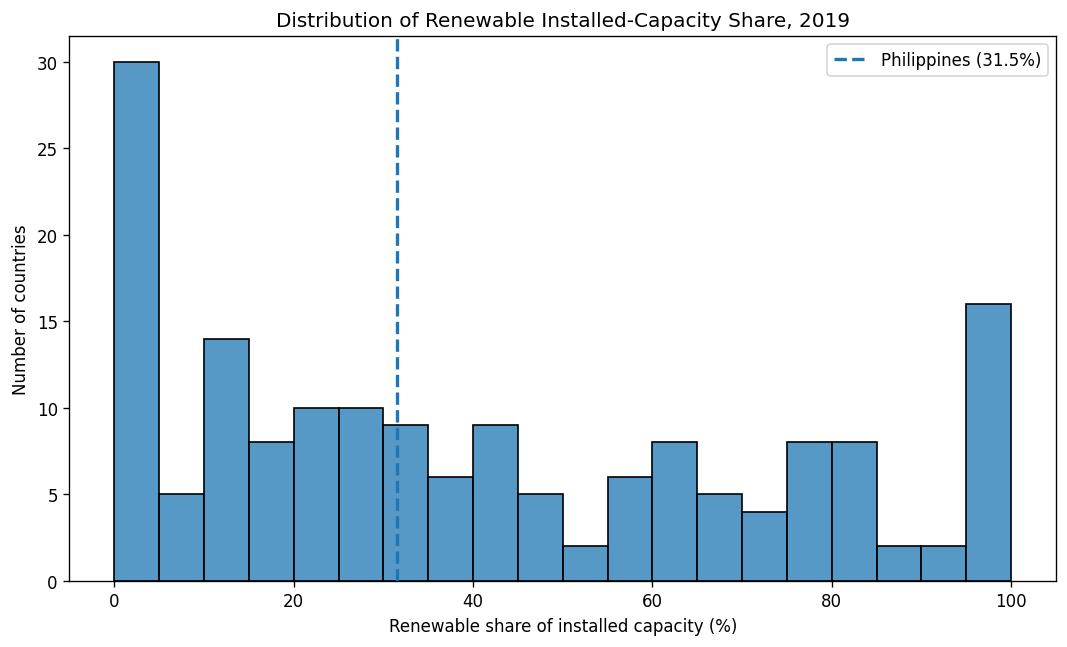

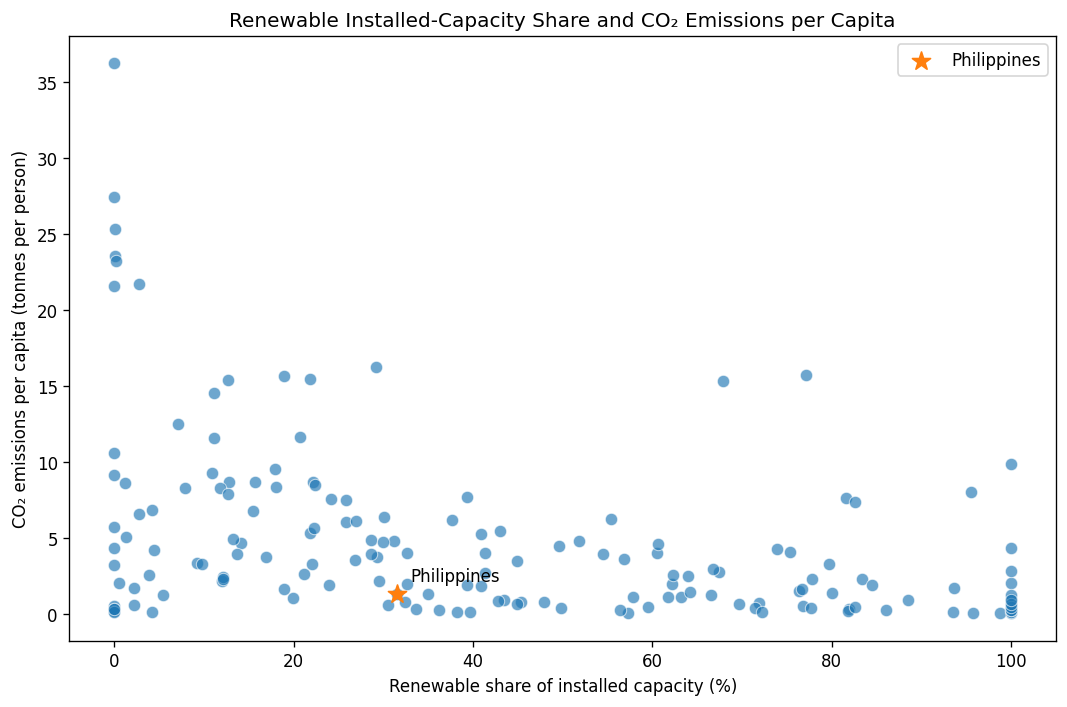


FIGURES SAVED
/content/outputs/analysis/01_renewable_share_distribution.png
/content/outputs/analysis/02_renewable_vs_co2_per_capita.png


In [4]:
# ============================================================
# EXPLORATORY COUNTRY-LEVEL PROFILE
# ============================================================

# ------------------------------------------------------------
# 1. VARIABLES RELEVANT TO THE RESEARCH QUESTION
# ------------------------------------------------------------

eda_features = [
    "total_installed_capacity_mw",
    "renewable_share_pct",
    "fossil_share_pct",
    "coal_share_pct",
    "gas_share_pct",
    "oil_share_pct",
    "hydro_share_pct",
    "solar_share_pct",
    "wind_share_pct",
    "geothermal_share_pct",
    "co2_per_capita",
    "co2_per_gdp",
    "gdp_per_capita_current_usd",
]

eda_features = [
    col for col in eda_features
    if col in country_level.columns
]

print("=" * 75)
print("COUNTRY-LEVEL DESCRIPTIVE STATISTICS")
print("=" * 75)

descriptive_stats = (
    country_level[eda_features]
    .describe()
    .T
    .rename(
        columns={
            "count": "n",
            "mean": "mean",
            "std": "std",
            "min": "min",
            "25%": "q1",
            "50%": "median",
            "75%": "q3",
            "max": "max",
        }
    )
)

display(
    descriptive_stats[
        ["n", "mean", "std", "min", "q1", "median", "q3", "max"]
    ].round(3)
)

# ------------------------------------------------------------
# 2. SKEWNESS CHECK
# ------------------------------------------------------------

skew_features = [
    "total_installed_capacity_mw",
    "co2_per_capita",
    "co2_per_gdp",
    "gdp_per_capita_current_usd",
]

skew_features = [
    col for col in skew_features
    if col in country_level.columns
]

skewness_table = pd.DataFrame({
    "variable": skew_features,
    "skewness": [
        country_level[col].dropna().skew()
        for col in skew_features
    ],
    "missing_countries": [
        country_level[col].isna().sum()
        for col in skew_features
    ],
})

print("\nSKEWNESS OF CONTINUOUS VARIABLES")
display(skewness_table.round(3))

# ------------------------------------------------------------
# 3. POTENTIAL CLUSTERING FEATURE SET
# ------------------------------------------------------------
# This is only a candidate set. We will finalize it after
# inspecting correlations and distributions.

candidate_cluster_features = [
    "renewable_share_pct",
    "coal_share_pct",
    "gas_share_pct",
    "oil_share_pct",
    "co2_per_capita",
    "gdp_per_capita_current_usd",
]

candidate_cluster_features = [
    col for col in candidate_cluster_features
    if col in country_level.columns
]

candidate_data = country_level[
    ["country_code", "country_name"] + candidate_cluster_features
].copy()

complete_candidate = candidate_data.dropna(
    subset=candidate_cluster_features
)

print("\nCANDIDATE CLUSTERING DATA")
print(
    f"Countries available before missing-value handling: "
    f"{len(country_level)}"
)
print(
    f"Countries with complete candidate features: "
    f"{len(complete_candidate)}"
)
print(
    f"Countries excluded by complete-case approach: "
    f"{len(country_level) - len(complete_candidate)}"
)
print(
    "Philippines complete: "
    f"{complete_candidate['country_code'].eq('PHL').any()}"
)

# ------------------------------------------------------------
# 4. CORRELATION / REDUNDANCY CHECK
# ------------------------------------------------------------

correlation_features = [
    "renewable_share_pct",
    "fossil_share_pct",
    "coal_share_pct",
    "gas_share_pct",
    "oil_share_pct",
    "co2_per_capita",
    "co2_per_gdp",
    "gdp_per_capita_current_usd",
]

correlation_features = [
    col for col in correlation_features
    if col in country_level.columns
]

correlation_matrix = (
    country_level[correlation_features]
    .corr(method="spearman")
)

print("\nSPEARMAN CORRELATION MATRIX")
display(correlation_matrix.round(3))

# Identify very strong relationships that may indicate redundancy
strong_pairs = []

for i, col1 in enumerate(correlation_matrix.columns):
    for col2 in correlation_matrix.columns[i + 1:]:
        corr = correlation_matrix.loc[col1, col2]

        if abs(corr) >= 0.80:
            strong_pairs.append({
                "variable_1": col1,
                "variable_2": col2,
                "spearman_correlation": corr,
            })

strong_correlations = pd.DataFrame(strong_pairs)

print("\nVERY STRONG CORRELATIONS (|r| >= 0.80)")

if strong_correlations.empty:
    print("None detected.")
else:
    display(
        strong_correlations
        .sort_values(
            "spearman_correlation",
            key=lambda x: x.abs(),
            ascending=False,
        )
        .round(3)
    )

# ------------------------------------------------------------
# 5. FIGURE 1 — RENEWABLE INSTALLED-CAPACITY SHARE
# ------------------------------------------------------------

phl = country_level.loc[
    country_level["country_code"].eq("PHL")
].iloc[0]

fig, ax = plt.subplots(figsize=(9, 5.5))

sns.histplot(
    data=country_level,
    x="renewable_share_pct",
    bins=20,
    ax=ax,
)

ax.axvline(
    phl["renewable_share_pct"],
    linestyle="--",
    linewidth=2,
    label=(
        f"Philippines "
        f"({phl['renewable_share_pct']:.1f}%)"
    ),
)

ax.set_title(
    "Distribution of Renewable Installed-Capacity Share, 2019"
)
ax.set_xlabel(
    "Renewable share of installed capacity (%)"
)
ax.set_ylabel("Number of countries")
ax.legend()

fig.tight_layout()

fig.savefig(
    OUTPUT_DIR / "01_renewable_share_distribution.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

# ------------------------------------------------------------
# 6. FIGURE 2 — RENEWABLE SHARE VS CO2 PER CAPITA
# ------------------------------------------------------------

plot_data = country_level.dropna(
    subset=[
        "renewable_share_pct",
        "co2_per_capita",
    ]
).copy()

fig, ax = plt.subplots(figsize=(9, 6))

sns.scatterplot(
    data=plot_data,
    x="renewable_share_pct",
    y="co2_per_capita",
    alpha=0.65,
    s=55,
    ax=ax,
)

# Highlight the Philippines
ax.scatter(
    phl["renewable_share_pct"],
    phl["co2_per_capita"],
    s=130,
    marker="*",
    label="Philippines",
    zorder=5,
)

ax.annotate(
    "Philippines",
    (
        phl["renewable_share_pct"],
        phl["co2_per_capita"],
    ),
    xytext=(8, 8),
    textcoords="offset points",
)

ax.set_title(
    "Renewable Installed-Capacity Share and CO₂ Emissions per Capita"
)
ax.set_xlabel(
    "Renewable share of installed capacity (%)"
)
ax.set_ylabel(
    "CO₂ emissions per capita (tonnes per person)"
)
ax.legend()

fig.tight_layout()

fig.savefig(
    OUTPUT_DIR / "02_renewable_vs_co2_per_capita.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("\nFIGURES SAVED")
print(
    OUTPUT_DIR / "01_renewable_share_distribution.png"
)
print(
    OUTPUT_DIR / "02_renewable_vs_co2_per_capita.png"
)

## Country Clustering

K-Means clustering is used to group countries with similar installed-capacity structures, carbon intensity, and economic conditions.

The clustering variables were selected after examining their distributions and correlations. The final candidate feature set includes:

- renewable installed-capacity share;
- coal installed-capacity share;
- gas installed-capacity share;
- oil installed-capacity share;
- CO₂ intensity relative to GDP; and
- GDP per capita.

`fossil_share_pct` is excluded because it is strongly inversely correlated with renewable capacity share and would duplicate the same underlying capacity-mix information.

CO₂ per capita is retained for later benchmarking but is not included in the clustering model because it is strongly associated with GDP per capita in this dataset. Instead, the available CO₂-per-GDP indicator is used to represent the carbon-intensity dimension while GDP per capita represents economic conditions.

Countries with missing values in the selected clustering variables are excluded from the K-Means model rather than statistically imputed because the amount of missingness is relatively small. This avoids creating artificial national profiles.

GDP per capita and CO₂ per GDP are positively skewed, so logarithmic transformations are applied before clustering. Installed-capacity shares remain as percentages. All final clustering variables are then standardized so that differences in measurement scale do not cause one variable to dominate the distance calculations.

A range of cluster counts from K = 2 to K = 8 is evaluated using:

- **inertia (elbow method)** — measures within-cluster variation; and
- **silhouette score** — measures how well countries fit their assigned clusters relative to neighboring clusters.

The final number of clusters will be selected after considering both measures together rather than relying on a single statistic.

CLUSTERING SAMPLE
Total countries in country-level dataset: 167
Countries retained for clustering:       152
Countries excluded for missing values:   15
Philippines retained:                   True

SKEWNESS BEFORE AND AFTER TRANSFORMATION


,variable,skewness
0,co2_per_gdp,2.212
1,log_co2_per_gdp,1.621
2,gdp_per_capita_current_usd,2.052
3,log_gdp_per_capita,0.007



STANDARDIZATION CHECK


,feature,scaled_mean,scaled_std
0,renewable_share_pct,-0.000,1.000
1,coal_share_pct,-0.000,1.000
2,gas_share_pct,0.000,1.000
3,oil_share_pct,0.000,1.000
4,log_co2_per_gdp,0.000,1.000
5,log_gdp_per_capita,-0.000,1.000



K-MEANS EVALUATION


,k,inertia,silhouette_score,inertia_reduction_pct
0,2,685.88,0.239,nan%
1,3,542.78,0.283,20.9%
2,4,409.22,0.323,24.6%
3,5,343.09,0.300,16.2%
4,6,306.46,0.263,10.7%
5,7,280.91,0.266,8.3%
6,8,254.81,0.274,9.3%



Highest silhouette score occurs at K = 4.
This is not automatically the final K; the elbow pattern will also be considered.


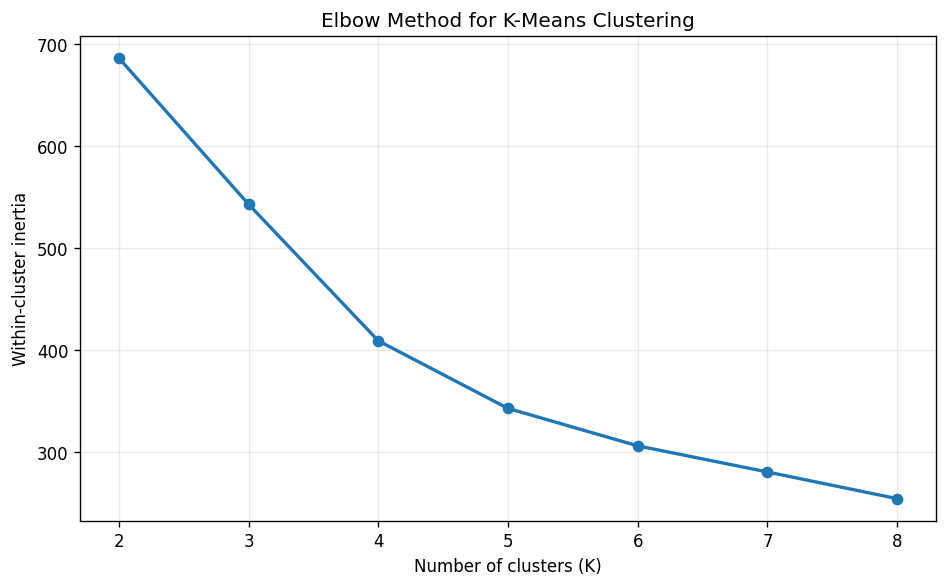

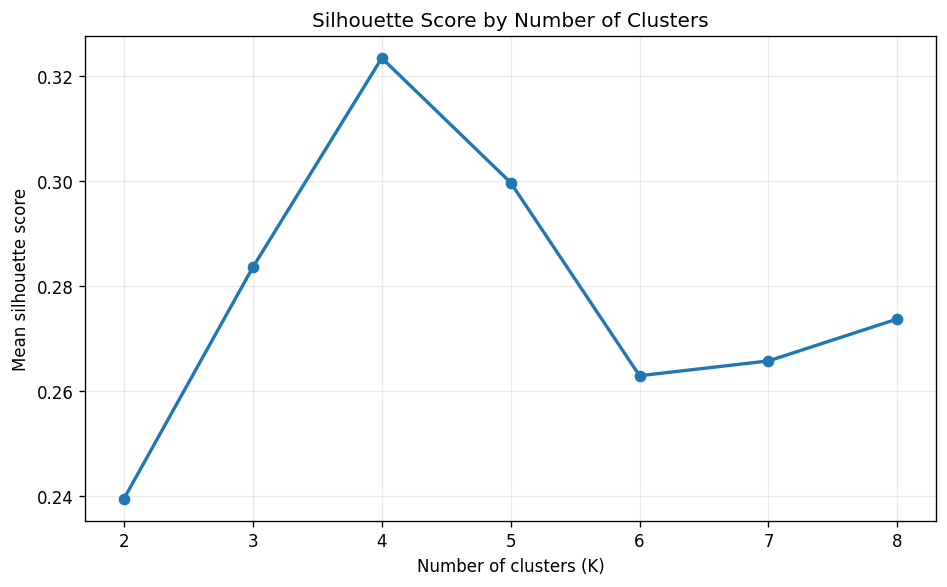


FIGURES SAVED
/content/outputs/analysis/03_kmeans_elbow_curve.png
/content/outputs/analysis/04_kmeans_silhouette_scores.png


In [5]:
# ============================================================
# PREPARE CLUSTERING DATA AND EVALUATE K = 2 TO 8
# ============================================================

# ------------------------------------------------------------
# 1. FINAL CANDIDATE FEATURES
# ------------------------------------------------------------

cluster_features_raw = [
    "renewable_share_pct",
    "coal_share_pct",
    "gas_share_pct",
    "oil_share_pct",
    "co2_per_gdp",
    "gdp_per_capita_current_usd",
]

# Use complete country observations only
cluster_data = (
    country_level[
        [
            "country_code",
            "country_name",
        ] + cluster_features_raw
    ]
    .dropna(subset=cluster_features_raw)
    .copy()
    .reset_index(drop=True)
)

print("=" * 75)
print("CLUSTERING SAMPLE")
print("=" * 75)
print(f"Total countries in country-level dataset: {len(country_level)}")
print(f"Countries retained for clustering:       {len(cluster_data)}")
print(
    f"Countries excluded for missing values:   "
    f"{len(country_level) - len(cluster_data)}"
)
print(
    "Philippines retained:                   "
    f"{cluster_data['country_code'].eq('PHL').any()}"
)

assert cluster_data["country_code"].is_unique
assert cluster_data["country_code"].eq("PHL").any()


# ------------------------------------------------------------
# 2. LOG-TRANSFORM SKEWED CONTINUOUS VARIABLES
# ------------------------------------------------------------

cluster_data["log_co2_per_gdp"] = np.log1p(
    cluster_data["co2_per_gdp"]
)

cluster_data["log_gdp_per_capita"] = np.log1p(
    cluster_data["gdp_per_capita_current_usd"]
)

cluster_features_model = [
    "renewable_share_pct",
    "coal_share_pct",
    "gas_share_pct",
    "oil_share_pct",
    "log_co2_per_gdp",
    "log_gdp_per_capita",
]

# Check whether transformation reduced skewness
transformation_check = pd.DataFrame({
    "variable": [
        "co2_per_gdp",
        "log_co2_per_gdp",
        "gdp_per_capita_current_usd",
        "log_gdp_per_capita",
    ],
    "skewness": [
        cluster_data["co2_per_gdp"].skew(),
        cluster_data["log_co2_per_gdp"].skew(),
        cluster_data["gdp_per_capita_current_usd"].skew(),
        cluster_data["log_gdp_per_capita"].skew(),
    ],
})

print("\nSKEWNESS BEFORE AND AFTER TRANSFORMATION")
display(transformation_check.round(3))


# ------------------------------------------------------------
# 3. PREPARE AND STANDARDIZE MODEL MATRIX
# ------------------------------------------------------------

X = cluster_data[cluster_features_model].copy()

# Final finite-value check
assert not X.isna().any().any(), "NaN values remain in clustering input."
assert np.isfinite(X.to_numpy()).all(), \
    "Infinite values detected in clustering input."

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=cluster_features_model,
    index=cluster_data.index,
)

# Verify standardization
standardization_check = pd.DataFrame({
    "feature": cluster_features_model,
    "scaled_mean": X_scaled_df.mean().values,
    "scaled_std": X_scaled_df.std(ddof=0).values,
})

print("\nSTANDARDIZATION CHECK")
display(standardization_check.round(3))


# ------------------------------------------------------------
# 4. TEST K = 2 THROUGH K = 8
# ------------------------------------------------------------

k_values = range(2, 9)

k_results = []

for k in k_values:

    model = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=50,
    )

    labels = model.fit_predict(X_scaled)

    k_results.append({
        "k": k,
        "inertia": model.inertia_,
        "silhouette_score": silhouette_score(
            X_scaled,
            labels,
        ),
    })

k_evaluation = pd.DataFrame(k_results)

# Helpful measure of the percentage drop in inertia
k_evaluation["inertia_reduction_pct"] = (
    -k_evaluation["inertia"]
    .pct_change()
    * 100
)

print("\nK-MEANS EVALUATION")
display(
    k_evaluation.style.format({
        "inertia": "{:.2f}",
        "silhouette_score": "{:.3f}",
        "inertia_reduction_pct": "{:.1f}%",
    })
)

best_silhouette_k = int(
    k_evaluation.loc[
        k_evaluation["silhouette_score"].idxmax(),
        "k",
    ]
)

print(
    "\nHighest silhouette score occurs at "
    f"K = {best_silhouette_k}."
)
print(
    "This is not automatically the final K; "
    "the elbow pattern will also be considered."
)


# ------------------------------------------------------------
# 5. ELBOW PLOT
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    k_evaluation["k"],
    k_evaluation["inertia"],
    marker="o",
    linewidth=2,
)

ax.set_title(
    "Elbow Method for K-Means Clustering"
)
ax.set_xlabel("Number of clusters (K)")
ax.set_ylabel("Within-cluster inertia")
ax.set_xticks(list(k_values))
ax.grid(alpha=0.25)

fig.tight_layout()

fig.savefig(
    OUTPUT_DIR / "03_kmeans_elbow_curve.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()


# ------------------------------------------------------------
# 6. SILHOUETTE SCORE PLOT
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    k_evaluation["k"],
    k_evaluation["silhouette_score"],
    marker="o",
    linewidth=2,
)

ax.set_title(
    "Silhouette Score by Number of Clusters"
)
ax.set_xlabel("Number of clusters (K)")
ax.set_ylabel("Mean silhouette score")
ax.set_xticks(list(k_values))
ax.grid(alpha=0.25)

fig.tight_layout()

fig.savefig(
    OUTPUT_DIR / "04_kmeans_silhouette_scores.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()


print("\nFIGURES SAVED")
print(
    OUTPUT_DIR / "03_kmeans_elbow_curve.png"
)
print(
    OUTPUT_DIR / "04_kmeans_silhouette_scores.png"
)

FINAL K-MEANS MODEL
Selected number of clusters: K = 4
Selection rationale: K=4 produced the highest silhouette score (0.323) and is also supported by the elbow pattern.
Countries modeled: 152
Countries excluded because of missing clustering features: 15

CLUSTER SIZES


,country_count
cluster,
1,40
2,61
3,21
4,30



CLUSTER PROFILES — RAW-SCALE MEANS


,cluster,country_count,renewable_share_pct,fossil_share_pct,coal_share_pct,gas_share_pct,oil_share_pct,co2_per_gdp,co2_per_capita,mean_gdp_per_capita_usd,median_gdp_per_capita_usd
0,1,40,16.5,79.3,6.3,65.4,7.5,0.293,8.18,"$22,261","$10,909"
1,2,61,75.2,22.0,4.9,9.2,7.9,0.161,2.50,"$14,372","$4,082"
2,3,21,15.3,84.7,2.9,15.2,66.6,0.262,3.26,"$5,942","$2,837"
3,4,30,24.9,69.1,54.9,12.5,1.7,0.341,6.29,"$14,397","$8,575"



STANDARDIZED CLUSTER CENTERS (0 = clustering-sample average)


,Renewable capacity share,Coal capacity share,Gas capacity share,Oil capacity share,CO₂ intensity,GDP per capita
cluster,,,,,,
1,-0.780,-0.370,1.390,-0.300,0.310,0.470
2,1.040,-0.430,-0.570,-0.280,-0.550,-0.260
3,-0.810,-0.520,-0.360,2.170,0.120,-0.520
4,-0.520,1.740,-0.450,-0.540,0.620,0.260


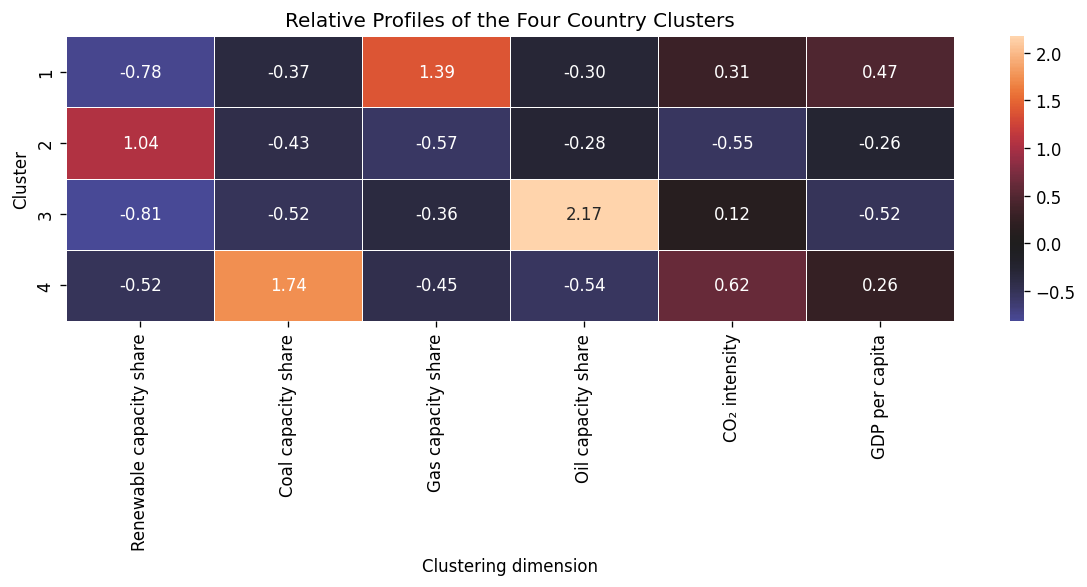

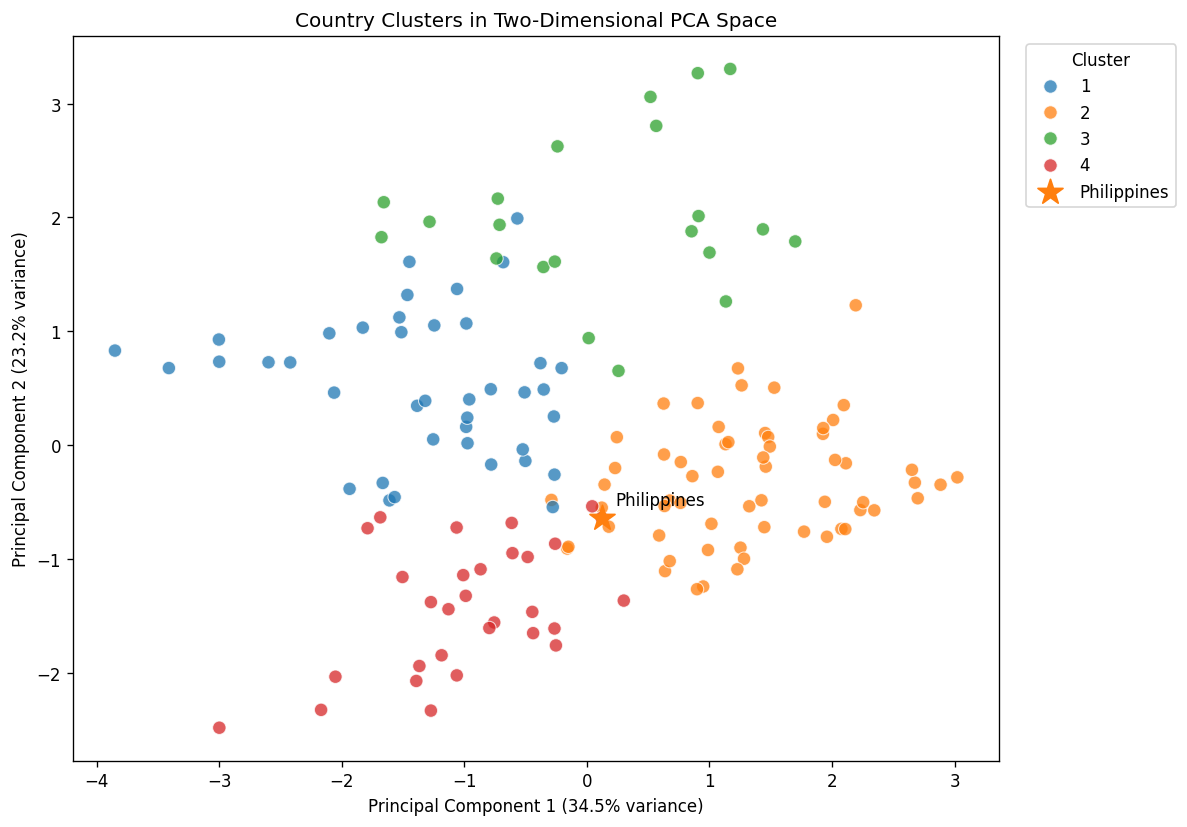


PCA variance explained by first two components: 57.7%

PHILIPPINES CLUSTER
Philippines belongs to Cluster 4.
Number of countries in Cluster 4: 30

Countries in the same cluster:
Australia, Bosnia and Herzegovina, Botswana, Bulgaria, China, Czech Republic, Denmark, Germany, Greece, India, Indonesia, Kazakhstan, Laos, Macedonia, Malaysia, Moldova, Mongolia, Morocco, Philippines, Poland, Romania, Serbia, Slovakia, Slovenia, South Africa, South Korea, Turkey, Ukraine, Vietnam, Zimbabwe

PHILIPPINES CLUSTER — COUNTRY PROFILES


,country_code,country_name,renewable_share_pct,fossil_share_pct,coal_share_pct,gas_share_pct,oil_share_pct,co2_per_capita,co2_per_gdp,gdp_per_capita_current_usd
0,AUS,Australia,29.2,70.8,38.8,30.4,1.7,16.28,0.330,"$55,195"
1,BIH,Bosnia and Herzegovina,55.3,44.7,44.7,0.0,0.0,6.22,0.478,"$6,122"
2,BWA,Botswana,0.0,100.0,100.0,0.0,0.0,3.21,0.207,"$7,172"
3,BGR,Bulgaria,25.9,52.5,52.5,0.0,0.0,6.05,0.326,"$10,354"
4,CHN,China,25.8,71.9,67.5,4.2,0.1,7.53,0.453,"$10,343"
5,CZE,Czech Republic,17.9,57.4,49.6,7.8,0.0,9.57,0.295,"$24,063"
6,DNK,Denmark,21.8,78.2,62.9,7.1,8.2,5.32,0.110,"$59,404"
7,DEU,Germany,22.4,67.0,42.6,21.8,2.5,8.48,0.182,"$47,656"
8,GRC,Greece,27.0,73.0,34.1,35.5,3.4,6.13,0.260,"$19,335"
9,IND,India,24.0,73.3,64.8,7.9,0.5,1.88,0.272,"$2,041"



Saved: /content/outputs/analysis/country_clusters.csv


In [6]:
# ============================================================
# FINAL K-MEANS MODEL, CLUSTER PROFILES, AND PCA VISUALIZATION
# ============================================================

FINAL_K = 4

# ------------------------------------------------------------
# 1. FIT FINAL K-MEANS MODEL
# ------------------------------------------------------------

final_kmeans = KMeans(
    n_clusters=FINAL_K,
    random_state=RANDOM_STATE,
    n_init=50,
)

final_labels = final_kmeans.fit_predict(X_scaled)

# Convert arbitrary 0-based sklearn labels to 1-based labels
# for easier presentation.
cluster_data["cluster"] = final_labels + 1

assert cluster_data["cluster"].notna().all()
assert cluster_data["cluster"].between(1, FINAL_K).all()

print("=" * 75)
print("FINAL K-MEANS MODEL")
print("=" * 75)
print(f"Selected number of clusters: K = {FINAL_K}")
print(
    "Selection rationale: K=4 produced the highest silhouette "
    "score (0.323) and is also supported by the elbow pattern."
)
print(f"Countries modeled: {len(cluster_data)}")


# ------------------------------------------------------------
# 2. ATTACH CLUSTER ASSIGNMENTS TO COUNTRY-LEVEL DATA
# ------------------------------------------------------------

cluster_assignments = cluster_data[
    [
        "country_code",
        "cluster",
    ]
].copy()

country_clusters = country_level.merge(
    cluster_assignments,
    on="country_code",
    how="left",
    validate="one_to_one",
)

country_clusters["included_in_clustering"] = (
    country_clusters["cluster"].notna()
)

country_clusters["cluster"] = (
    country_clusters["cluster"]
    .astype("Int64")
)

# Validate that every modeled country received a cluster
assert (
    country_clusters.loc[
        country_clusters["included_in_clustering"],
        "cluster",
    ]
    .notna()
    .all()
)

print(
    f"Countries excluded because of missing clustering features: "
    f"{(~country_clusters['included_in_clustering']).sum()}"
)


# ------------------------------------------------------------
# 3. CLUSTER SIZES
# ------------------------------------------------------------

cluster_sizes = (
    cluster_data["cluster"]
    .value_counts()
    .sort_index()
    .rename("country_count")
    .to_frame()
)

print("\nCLUSTER SIZES")
display(cluster_sizes)


# ------------------------------------------------------------
# 4. RAW-SCALE CLUSTER PROFILES
# ------------------------------------------------------------
# Means are shown here because K-Means itself is a centroid-
# based method. GDP median is included as additional context
# because GDP per capita is strongly skewed on its raw scale.

modeled_countries = country_clusters[
    country_clusters["included_in_clustering"]
].copy()

cluster_profiles = (
    modeled_countries
    .groupby("cluster")
    .agg(
        country_count=("country_code", "size"),

        renewable_share_pct=(
            "renewable_share_pct",
            "mean",
        ),
        fossil_share_pct=(
            "fossil_share_pct",
            "mean",
        ),
        coal_share_pct=(
            "coal_share_pct",
            "mean",
        ),
        gas_share_pct=(
            "gas_share_pct",
            "mean",
        ),
        oil_share_pct=(
            "oil_share_pct",
            "mean",
        ),

        co2_per_gdp=(
            "co2_per_gdp",
            "mean",
        ),
        co2_per_capita=(
            "co2_per_capita",
            "mean",
        ),

        mean_gdp_per_capita_usd=(
            "gdp_per_capita_current_usd",
            "mean",
        ),
        median_gdp_per_capita_usd=(
            "gdp_per_capita_current_usd",
            "median",
        ),
    )
    .reset_index()
)

print("\nCLUSTER PROFILES — RAW-SCALE MEANS")
display(
    cluster_profiles.style.format({
        "renewable_share_pct": "{:.1f}",
        "fossil_share_pct": "{:.1f}",
        "coal_share_pct": "{:.1f}",
        "gas_share_pct": "{:.1f}",
        "oil_share_pct": "{:.1f}",
        "co2_per_gdp": "{:.3f}",
        "co2_per_capita": "{:.2f}",
        "mean_gdp_per_capita_usd": "${:,.0f}",
        "median_gdp_per_capita_usd": "${:,.0f}",
    })
)


# ------------------------------------------------------------
# 5. STANDARDIZED CLUSTER CENTERS
# ------------------------------------------------------------
# These are the actual K-Means centroids used by the model.
# Positive values are above the clustering-sample average,
# while negative values are below the average.

centroid_profiles = pd.DataFrame(
    final_kmeans.cluster_centers_,
    columns=cluster_features_model,
)

centroid_profiles["cluster"] = (
    np.arange(FINAL_K) + 1
)

centroid_profiles = (
    centroid_profiles
    .set_index("cluster")
)

centroid_display = centroid_profiles.rename(
    columns={
        "renewable_share_pct":
            "Renewable capacity share",
        "coal_share_pct":
            "Coal capacity share",
        "gas_share_pct":
            "Gas capacity share",
        "oil_share_pct":
            "Oil capacity share",
        "log_co2_per_gdp":
            "CO₂ intensity",
        "log_gdp_per_capita":
            "GDP per capita",
    }
)

print(
    "\nSTANDARDIZED CLUSTER CENTERS "
    "(0 = clustering-sample average)"
)
display(centroid_display.round(2))


# ------------------------------------------------------------
# 6. CLUSTER PROFILE HEATMAP
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 5))

sns.heatmap(
    centroid_display,
    annot=True,
    fmt=".2f",
    center=0,
    linewidths=0.5,
    ax=ax,
)

ax.set_title(
    "Relative Profiles of the Four Country Clusters"
)
ax.set_xlabel("Clustering dimension")
ax.set_ylabel("Cluster")

fig.tight_layout()

fig.savefig(
    OUTPUT_DIR / "05_cluster_profile_heatmap.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()


# ------------------------------------------------------------
# 7. PCA FOR TWO-DIMENSIONAL VISUALIZATION ONLY
# ------------------------------------------------------------

pca = PCA(
    n_components=2,
    random_state=RANDOM_STATE,
)

pca_coordinates = pca.fit_transform(
    X_scaled
)

pca_plot = cluster_data[
    [
        "country_code",
        "country_name",
        "cluster",
    ]
].copy()

pca_plot["PC1"] = pca_coordinates[:, 0]
pca_plot["PC2"] = pca_coordinates[:, 1]

pc1_variance = (
    pca.explained_variance_ratio_[0] * 100
)
pc2_variance = (
    pca.explained_variance_ratio_[1] * 100
)

fig, ax = plt.subplots(figsize=(10, 7))

sns.scatterplot(
    data=pca_plot,
    x="PC1",
    y="PC2",
    hue="cluster",
    palette="tab10",
    s=65,
    alpha=0.75,
    ax=ax,
)

phl_pca = pca_plot.loc[
    pca_plot["country_code"].eq("PHL")
].iloc[0]

ax.scatter(
    phl_pca["PC1"],
    phl_pca["PC2"],
    marker="*",
    s=250,
    label="Philippines",
    zorder=5,
)

ax.annotate(
    "Philippines",
    (
        phl_pca["PC1"],
        phl_pca["PC2"],
    ),
    xytext=(8, 8),
    textcoords="offset points",
)

ax.set_title(
    "Country Clusters in Two-Dimensional PCA Space"
)

ax.set_xlabel(
    f"Principal Component 1 "
    f"({pc1_variance:.1f}% variance)"
)

ax.set_ylabel(
    f"Principal Component 2 "
    f"({pc2_variance:.1f}% variance)"
)

ax.legend(
    title="Cluster",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

fig.tight_layout()

fig.savefig(
    OUTPUT_DIR / "06_country_clusters_pca.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(
    "\nPCA variance explained by first two components: "
    f"{pc1_variance + pc2_variance:.1f}%"
)


# ------------------------------------------------------------
# 8. IDENTIFY THE PHILIPPINES' CLUSTER
# ------------------------------------------------------------

phl_cluster = int(
    cluster_data.loc[
        cluster_data["country_code"].eq("PHL"),
        "cluster",
    ].iloc[0]
)

phl_cluster_countries = (
    modeled_countries.loc[
        modeled_countries["cluster"].eq(phl_cluster),
        [
            "country_code",
            "country_name",
            "renewable_share_pct",
            "fossil_share_pct",
            "coal_share_pct",
            "gas_share_pct",
            "oil_share_pct",
            "co2_per_capita",
            "co2_per_gdp",
            "gdp_per_capita_current_usd",
        ],
    ]
    .sort_values("country_name")
    .reset_index(drop=True)
)

print("\n" + "=" * 75)
print("PHILIPPINES CLUSTER")
print("=" * 75)
print(f"Philippines belongs to Cluster {phl_cluster}.")
print(
    f"Number of countries in Cluster {phl_cluster}: "
    f"{len(phl_cluster_countries)}"
)

print(
    "\nCountries in the same cluster:\n"
    + ", ".join(
        phl_cluster_countries["country_name"]
    )
)

print(
    "\nPHILIPPINES CLUSTER — COUNTRY PROFILES"
)

display(
    phl_cluster_countries.style.format({
        "renewable_share_pct": "{:.1f}",
        "fossil_share_pct": "{:.1f}",
        "coal_share_pct": "{:.1f}",
        "gas_share_pct": "{:.1f}",
        "oil_share_pct": "{:.1f}",
        "co2_per_capita": "{:.2f}",
        "co2_per_gdp": "{:.3f}",
        "gdp_per_capita_current_usd": "${:,.0f}",
    })
)


# ------------------------------------------------------------
# 9. SAVE CURRENT CLUSTER OUTPUT
# ------------------------------------------------------------

country_clusters.to_csv(
    OUTPUT_DIR / "country_clusters.csv",
    index=False,
)

print(
    "\nSaved:",
    OUTPUT_DIR / "country_clusters.csv",
)

## Philippines Cluster and Peer Benchmarking

The Philippines belongs to **Cluster 4**, a group characterized by comparatively high coal installed-capacity shares and above-average carbon intensity relative to GDP.

Cluster membership alone does not mean that all countries in the group are equally similar to the Philippines. Countries within the Philippine cluster therefore undergo a second comparison to identify more useful transition benchmarks.

Similarity is measured using Euclidean distance in the same standardized feature space used by the K-Means model. A smaller distance indicates that a country has a more similar overall combination of installed-capacity structure, carbon intensity, and GDP per capita.

Cleaner-energy benchmarking is then performed transparently rather than through an arbitrary weighted score. A country is considered a potential cleaner-energy benchmark when it:

- belongs to the same cluster as the Philippines;
- has GDP per capita between 0.5 and 2.0 times the Philippine level;
- has a higher renewable installed-capacity share;
- has a lower fossil installed-capacity share; and
- has a lower coal installed-capacity share.

CO₂ per capita and CO₂ per GDP are subsequently compared with the Philippines but are not required for cleaner-energy benchmark status. This distinction is necessary because a country may have a cleaner installed-capacity structure without having lower national carbon indicators.

A stricter comparison also identifies whether any same-cluster country combines both a cleaner installed-capacity structure and a lower carbon indicator than the Philippines.

The resulting countries should be interpreted as **comparative profiles and potential transition references**, not as countries whose energy systems or policies should simply be copied.

INTERPRETIVE CLUSTER LABELS


,cluster,cluster_label,country_count,renewable_share_pct,fossil_share_pct,coal_share_pct,gas_share_pct,oil_share_pct,co2_per_gdp,co2_per_capita,median_gdp_per_capita_usd
0,1,Gas-heavy / higher-income,40,16.5,79.3,6.3,65.4,7.5,0.293,8.18,"$10,909"
1,2,Renewable-heavy / lower-carbon-intensity,61,75.2,22.0,4.9,9.2,7.9,0.161,2.50,"$4,082"
2,3,Oil-heavy / lower-income,21,15.3,84.7,2.9,15.2,66.6,0.262,3.26,"$2,837"
3,4,Coal-heavy / higher-carbon-intensity,30,24.9,69.1,54.9,12.5,1.7,0.341,6.29,"$8,575"



PHILIPPINES PROFILE
Cluster: 4 — Coal-heavy / higher-carbon-intensity
Renewable share: 31.5%
Fossil share:    68.5%
Coal share:      42.1%
CO₂ per capita:  1.29 tonnes/person
CO₂ per GDP:     0.145
GDP per capita:  $3,401

10 NEAREST COUNTRIES TO THE PHILIPPINES WITHIN CLUSTER 4


,country_code,country_name,distance_to_philippines,renewable_share_pct,fossil_share_pct,coal_share_pct,co2_per_capita,co2_per_gdp,gdp_per_capita_current_usd
14,MAR,Morocco,0.753,39.3,60.7,32.6,1.90,0.223,"$3,508"
21,ROU,Romania,1.071,28.6,62.5,39.6,3.93,0.168,"$12,910"
25,TUR,Turkey,1.141,29.9,70.1,34.4,4.76,0.204,"$9,395"
9,IDN,Indonesia,1.189,12.1,87.9,60.2,2.44,0.203,"$4,107"
16,MKD,Macedonia,1.451,41.3,58.7,58.7,4.02,0.268,"$6,719"
10,IND,India,1.487,24.0,73.3,64.8,1.88,0.272,"$2,041"
8,GRC,Greece,1.679,27.0,73.0,34.1,6.13,0.260,"$19,335"
23,SVK,Slovakia,1.679,37.6,34.1,22.4,6.21,0.228,"$19,406"
24,SVN,Slovenia,1.689,15.4,59.1,48.3,6.75,0.221,"$25,814"
1,BGR,Bulgaria,1.710,25.9,52.5,52.5,6.05,0.326,"$10,354"



POTENTIAL CLEANER-ENERGY BENCHMARKS


,country_code,country_name,distance_to_philippines,gdp_ratio_to_philippines,renewable_share_pct,fossil_share_pct,coal_share_pct,co2_per_capita,co2_per_gdp,lower_co2_per_capita,lower_co2_per_gdp
14,MAR,Morocco,0.753,1.03x,39.3,60.7,32.6,1.90,0.223,False,False
13,LAO,Laos,1.976,0.76x,62.3,37.7,37.7,2.53,0.372,False,False
27,VNM,Vietnam,2.198,1.01x,44.9,55.1,34.2,3.49,0.464,False,False



STRICT ENERGY + CARBON BENCHMARK CHECK
No potential cleaner-energy benchmark also has a lower CO₂ per capita or lower CO₂-per-GDP value than the Philippines.

PHILIPPINES AND SELECTED PEER COUNTRIES


,country_code,country_name,cluster,cluster_label,renewable_share_pct,fossil_share_pct,coal_share_pct,gas_share_pct,oil_share_pct,co2_per_capita,co2_per_gdp,gdp_per_capita_current_usd
0,PHL,Philippines,4,Coal-heavy / higher-carbon-intensity,31.5,68.5,42.1,16.5,9.9,1.29,0.145,"$3,401"
1,LAO,Laos,4,Coal-heavy / higher-carbon-intensity,62.3,37.7,37.7,0.0,0.0,2.53,0.372,"$2,589"
2,MAR,Morocco,4,Coal-heavy / higher-carbon-intensity,39.3,60.7,32.6,19.2,8.9,1.90,0.223,"$3,508"
3,VNM,Vietnam,4,Coal-heavy / higher-carbon-intensity,44.9,55.1,34.2,18.7,2.2,3.49,0.464,"$3,441"


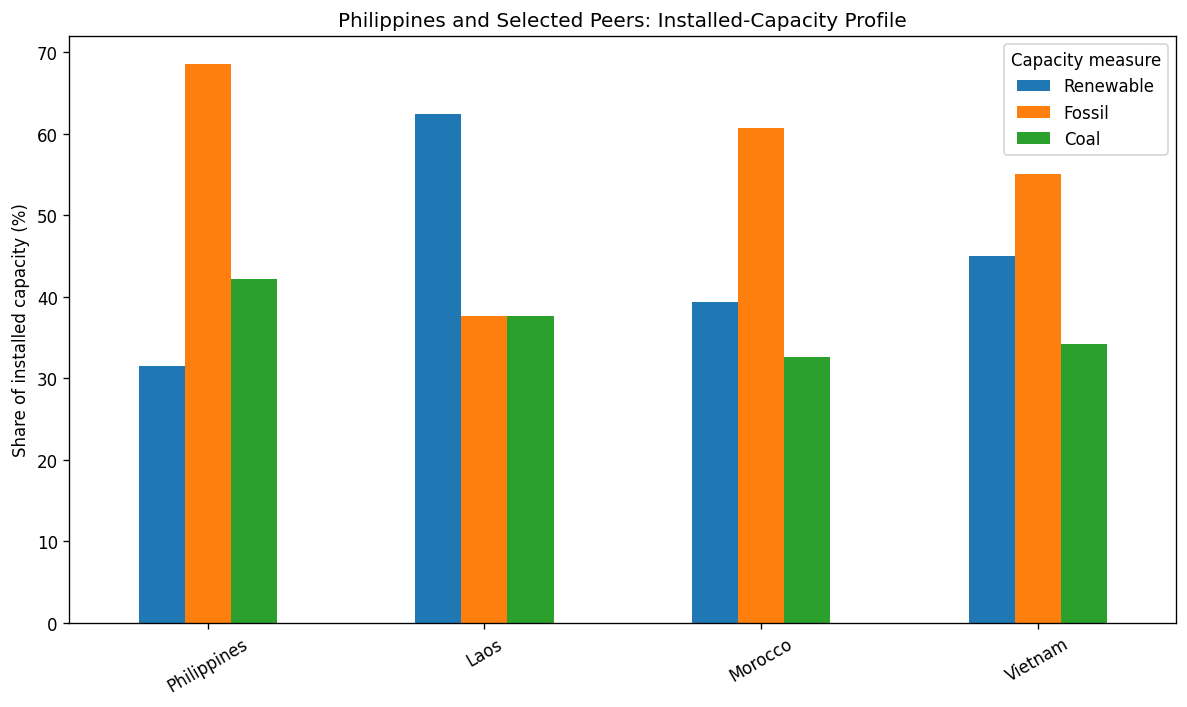

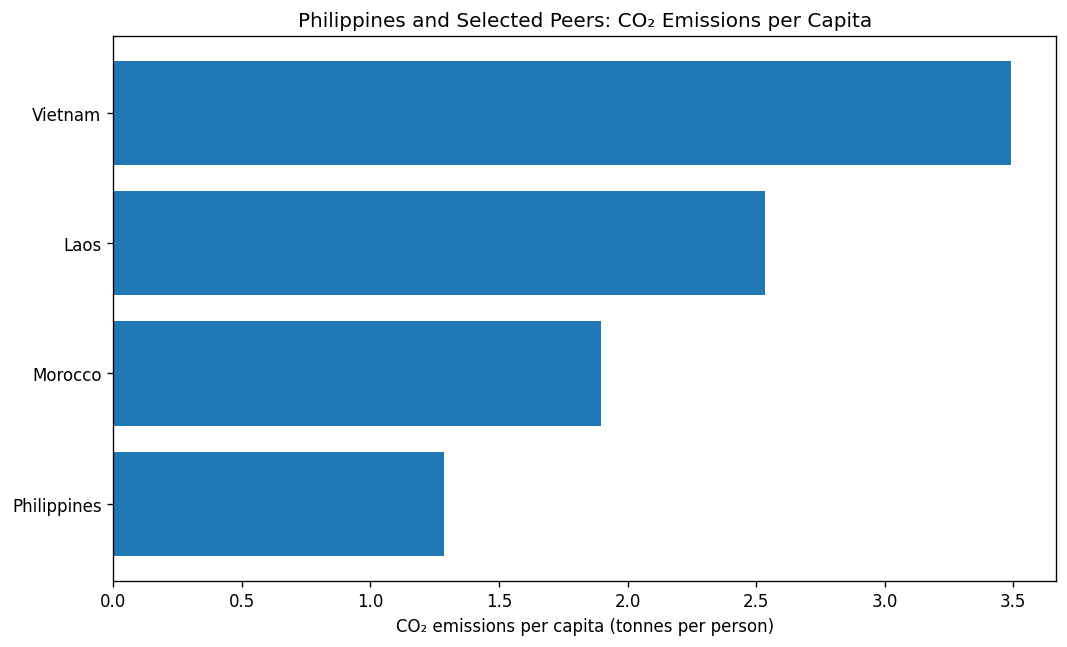


FILES SAVED
/content/outputs/analysis/philippines_peer_comparison.csv
/content/outputs/analysis/country_clusters.csv
/content/outputs/analysis/07_philippines_peer_capacity_comparison.png
/content/outputs/analysis/08_philippines_peer_co2_per_capita.png


In [7]:
# ============================================================
# PHILIPPINES PEER BENCHMARKING
# ============================================================

# ------------------------------------------------------------
# 1. INTERPRETIVE CLUSTER LABELS
# ------------------------------------------------------------
# These labels were assigned only after examining the actual
# cluster profiles produced in the previous section.

cluster_label_map = {
    1: "Gas-heavy / higher-income",
    2: "Renewable-heavy / lower-carbon-intensity",
    3: "Oil-heavy / lower-income",
    4: "Coal-heavy / higher-carbon-intensity",
}

country_clusters["cluster_label"] = (
    country_clusters["cluster"]
    .map(cluster_label_map)
)

cluster_profiles["cluster_label"] = (
    cluster_profiles["cluster"]
    .map(cluster_label_map)
)

print("=" * 80)
print("INTERPRETIVE CLUSTER LABELS")
print("=" * 80)

display(
    cluster_profiles[
        [
            "cluster",
            "cluster_label",
            "country_count",
            "renewable_share_pct",
            "fossil_share_pct",
            "coal_share_pct",
            "gas_share_pct",
            "oil_share_pct",
            "co2_per_gdp",
            "co2_per_capita",
            "median_gdp_per_capita_usd",
        ]
    ].style.format({
        "renewable_share_pct": "{:.1f}",
        "fossil_share_pct": "{:.1f}",
        "coal_share_pct": "{:.1f}",
        "gas_share_pct": "{:.1f}",
        "oil_share_pct": "{:.1f}",
        "co2_per_gdp": "{:.3f}",
        "co2_per_capita": "{:.2f}",
        "median_gdp_per_capita_usd": "${:,.0f}",
    })
)


# ------------------------------------------------------------
# 2. PHILIPPINES PROFILE
# ------------------------------------------------------------

phl_row = (
    country_clusters.loc[
        country_clusters["country_code"].eq("PHL")
    ]
    .iloc[0]
)

phl_cluster = int(phl_row["cluster"])

print("\n" + "=" * 80)
print("PHILIPPINES PROFILE")
print("=" * 80)

print(
    f"Cluster: {phl_cluster} — "
    f"{cluster_label_map[phl_cluster]}"
)
print(
    f"Renewable share: "
    f"{phl_row['renewable_share_pct']:.1f}%"
)
print(
    f"Fossil share:    "
    f"{phl_row['fossil_share_pct']:.1f}%"
)
print(
    f"Coal share:      "
    f"{phl_row['coal_share_pct']:.1f}%"
)
print(
    f"CO₂ per capita:  "
    f"{phl_row['co2_per_capita']:.2f} tonnes/person"
)
print(
    f"CO₂ per GDP:     "
    f"{phl_row['co2_per_gdp']:.3f}"
)
print(
    f"GDP per capita:  "
    f"${phl_row['gdp_per_capita_current_usd']:,.0f}"
)


# ------------------------------------------------------------
# 3. DISTANCE FROM PHILIPPINES IN K-MEANS FEATURE SPACE
# ------------------------------------------------------------

phl_model_index = cluster_data.index[
    cluster_data["country_code"].eq("PHL")
][0]

phl_vector = X_scaled[phl_model_index]

distance_to_phl = np.linalg.norm(
    X_scaled - phl_vector,
    axis=1,
)

distance_table = cluster_data[
    [
        "country_code",
        "country_name",
        "cluster",
    ]
].copy()

distance_table["distance_to_philippines"] = (
    distance_to_phl
)


# ------------------------------------------------------------
# 4. SAME-CLUSTER PEERS
# ------------------------------------------------------------

phl_cluster_peers = (
    country_clusters.loc[
        country_clusters["cluster"].eq(phl_cluster)
    ]
    .merge(
        distance_table[
            [
                "country_code",
                "distance_to_philippines",
            ]
        ],
        on="country_code",
        how="left",
        validate="one_to_one",
    )
    .copy()
)

# Remove the Philippines itself
phl_cluster_peers = (
    phl_cluster_peers.loc[
        ~phl_cluster_peers["country_code"].eq("PHL")
    ]
    .copy()
)


# ------------------------------------------------------------
# 5. TRANSPARENT COMPARISON CONDITIONS
# ------------------------------------------------------------

phl_gdp_pc = phl_row[
    "gdp_per_capita_current_usd"
]

phl_cluster_peers["gdp_ratio_to_philippines"] = (
    phl_cluster_peers[
        "gdp_per_capita_current_usd"
    ]
    / phl_gdp_pc
)

# Broad economic comparability:
# 0.5x to 2.0x Philippine GDP per capita
phl_cluster_peers["similar_economic_range"] = (
    phl_cluster_peers[
        "gdp_ratio_to_philippines"
    ]
    .between(0.5, 2.0)
)

phl_cluster_peers["higher_renewable"] = (
    phl_cluster_peers["renewable_share_pct"]
    > phl_row["renewable_share_pct"]
)

phl_cluster_peers["lower_fossil"] = (
    phl_cluster_peers["fossil_share_pct"]
    < phl_row["fossil_share_pct"]
)

phl_cluster_peers["lower_coal"] = (
    phl_cluster_peers["coal_share_pct"]
    < phl_row["coal_share_pct"]
)

phl_cluster_peers["lower_co2_per_capita"] = (
    phl_cluster_peers["co2_per_capita"]
    < phl_row["co2_per_capita"]
)

phl_cluster_peers["lower_co2_per_gdp"] = (
    phl_cluster_peers["co2_per_gdp"]
    < phl_row["co2_per_gdp"]
)

# Cleaner installed-capacity structure
phl_cluster_peers["cleaner_capacity_profile"] = (
    phl_cluster_peers["higher_renewable"]
    & phl_cluster_peers["lower_fossil"]
    & phl_cluster_peers["lower_coal"]
)

# Lower on at least one of the two carbon indicators
phl_cluster_peers["lower_any_carbon_indicator"] = (
    phl_cluster_peers["lower_co2_per_capita"]
    | phl_cluster_peers["lower_co2_per_gdp"]
)

# Main benchmark criterion
phl_cluster_peers["potential_energy_benchmark"] = (
    phl_cluster_peers["similar_economic_range"]
    & phl_cluster_peers["cleaner_capacity_profile"]
)

# Stricter benchmark criterion
phl_cluster_peers["energy_and_carbon_benchmark"] = (
    phl_cluster_peers["potential_energy_benchmark"]
    & phl_cluster_peers["lower_any_carbon_indicator"]
)


# ------------------------------------------------------------
# 6. NEAREST SAME-CLUSTER COUNTRIES
# ------------------------------------------------------------

nearest_peers = (
    phl_cluster_peers
    .sort_values("distance_to_philippines")
    .head(10)
)

print("\n" + "=" * 80)
print("10 NEAREST COUNTRIES TO THE PHILIPPINES WITHIN CLUSTER 4")
print("=" * 80)

display(
    nearest_peers[
        [
            "country_code",
            "country_name",
            "distance_to_philippines",
            "renewable_share_pct",
            "fossil_share_pct",
            "coal_share_pct",
            "co2_per_capita",
            "co2_per_gdp",
            "gdp_per_capita_current_usd",
        ]
    ].style.format({
        "distance_to_philippines": "{:.3f}",
        "renewable_share_pct": "{:.1f}",
        "fossil_share_pct": "{:.1f}",
        "coal_share_pct": "{:.1f}",
        "co2_per_capita": "{:.2f}",
        "co2_per_gdp": "{:.3f}",
        "gdp_per_capita_current_usd": "${:,.0f}",
    })
)


# ------------------------------------------------------------
# 7. POTENTIAL CLEANER-ENERGY BENCHMARKS
# ------------------------------------------------------------

benchmark_candidates = (
    phl_cluster_peers.loc[
        phl_cluster_peers[
            "potential_energy_benchmark"
        ]
    ]
    .sort_values(
        "distance_to_philippines"
    )
    .copy()
)

print("\n" + "=" * 80)
print("POTENTIAL CLEANER-ENERGY BENCHMARKS")
print("=" * 80)

if benchmark_candidates.empty:
    print(
        "No same-cluster countries satisfy all predefined "
        "economic and cleaner-capacity criteria."
    )

else:
    display(
        benchmark_candidates[
            [
                "country_code",
                "country_name",
                "distance_to_philippines",
                "gdp_ratio_to_philippines",
                "renewable_share_pct",
                "fossil_share_pct",
                "coal_share_pct",
                "co2_per_capita",
                "co2_per_gdp",
                "lower_co2_per_capita",
                "lower_co2_per_gdp",
            ]
        ].style.format({
            "distance_to_philippines": "{:.3f}",
            "gdp_ratio_to_philippines": "{:.2f}x",
            "renewable_share_pct": "{:.1f}",
            "fossil_share_pct": "{:.1f}",
            "coal_share_pct": "{:.1f}",
            "co2_per_capita": "{:.2f}",
            "co2_per_gdp": "{:.3f}",
        })
    )


# ------------------------------------------------------------
# 8. STRICT ENERGY + CARBON BENCHMARK CHECK
# ------------------------------------------------------------

strict_benchmarks = (
    benchmark_candidates.loc[
        benchmark_candidates[
            "energy_and_carbon_benchmark"
        ]
    ]
    .copy()
)

print("\nSTRICT ENERGY + CARBON BENCHMARK CHECK")

if strict_benchmarks.empty:
    print(
        "No potential cleaner-energy benchmark also has a "
        "lower CO₂ per capita or lower CO₂-per-GDP value "
        "than the Philippines."
    )
else:
    print(
        f"{len(strict_benchmarks)} country/countries satisfy "
        "both cleaner-capacity and lower-carbon criteria:"
    )
    print(
        ", ".join(
            strict_benchmarks["country_name"]
        )
    )


# ------------------------------------------------------------
# 9. SELECT PEERS FOR THE PRESENTATION TABLE
# ------------------------------------------------------------
# Select up to five closest qualifying cleaner-energy benchmarks.
# No weighted clean-energy score is used.

selected_peers = (
    benchmark_candidates
    .head(5)
    .copy()
)

# If fewer than three strict cleaner-capacity peers exist,
# supplement using the closest economically comparable peers
# with at least two improved capacity indicators.

if len(selected_peers) < 3:

    fallback = phl_cluster_peers.copy()

    fallback["capacity_improvement_count"] = (
        fallback[
            [
                "higher_renewable",
                "lower_fossil",
                "lower_coal",
            ]
        ]
        .sum(axis=1)
    )

    fallback = (
        fallback.loc[
            fallback["similar_economic_range"]
            & (
                fallback[
                    "capacity_improvement_count"
                ] >= 2
            )
            & ~fallback["country_code"].isin(
                selected_peers["country_code"]
            )
        ]
        .sort_values(
            [
                "capacity_improvement_count",
                "distance_to_philippines",
            ],
            ascending=[False, True],
        )
    )

    additional_needed = (
        3 - len(selected_peers)
    )

    selected_peers = pd.concat(
        [
            selected_peers,
            fallback.head(additional_needed),
        ],
        ignore_index=True,
    )


# ------------------------------------------------------------
# 10. FINAL PHILIPPINES + PEER COMPARISON TABLE
# ------------------------------------------------------------

comparison_codes = (
    ["PHL"]
    + selected_peers[
        "country_code"
    ].tolist()
)

philippines_peer_comparison = (
    country_clusters.loc[
        country_clusters[
            "country_code"
        ].isin(comparison_codes),
        [
            "country_code",
            "country_name",
            "cluster",
            "cluster_label",
            "renewable_share_pct",
            "fossil_share_pct",
            "coal_share_pct",
            "gas_share_pct",
            "oil_share_pct",
            "co2_per_capita",
            "co2_per_gdp",
            "gdp_per_capita_current_usd",
        ],
    ]
    .copy()
)

# Force Philippines to appear first
philippines_peer_comparison[
    "_display_order"
] = (
    philippines_peer_comparison[
        "country_code"
    ]
    .ne("PHL")
    .astype(int)
)

philippines_peer_comparison = (
    philippines_peer_comparison
    .sort_values(
        [
            "_display_order",
            "country_name",
        ]
    )
    .drop(columns="_display_order")
    .reset_index(drop=True)
)

print("\n" + "=" * 80)
print("PHILIPPINES AND SELECTED PEER COUNTRIES")
print("=" * 80)

display(
    philippines_peer_comparison.style.format({
        "renewable_share_pct": "{:.1f}",
        "fossil_share_pct": "{:.1f}",
        "coal_share_pct": "{:.1f}",
        "gas_share_pct": "{:.1f}",
        "oil_share_pct": "{:.1f}",
        "co2_per_capita": "{:.2f}",
        "co2_per_gdp": "{:.3f}",
        "gdp_per_capita_current_usd": "${:,.0f}",
    })
)


# ------------------------------------------------------------
# 11. FIGURE — INSTALLED-CAPACITY COMPARISON
# ------------------------------------------------------------

energy_plot = (
    philippines_peer_comparison[
        [
            "country_name",
            "renewable_share_pct",
            "fossil_share_pct",
            "coal_share_pct",
        ]
    ]
    .set_index("country_name")
)

ax = energy_plot.plot(
    kind="bar",
    figsize=(10, 6),
)

ax.set_title(
    "Philippines and Selected Peers: Installed-Capacity Profile"
)

ax.set_xlabel("")
ax.set_ylabel(
    "Share of installed capacity (%)"
)

ax.legend(
    [
        "Renewable",
        "Fossil",
        "Coal",
    ],
    title="Capacity measure",
)

ax.tick_params(
    axis="x",
    rotation=30,
)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR
    / "07_philippines_peer_capacity_comparison.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()


# ------------------------------------------------------------
# 12. FIGURE — CO2 PER CAPITA COMPARISON
# ------------------------------------------------------------

carbon_plot = (
    philippines_peer_comparison
    .sort_values(
        "co2_per_capita"
    )
)

fig, ax = plt.subplots(
    figsize=(9, 5.5)
)

ax.barh(
    carbon_plot["country_name"],
    carbon_plot["co2_per_capita"],
)

ax.set_title(
    "Philippines and Selected Peers: CO₂ Emissions per Capita"
)

ax.set_xlabel(
    "CO₂ emissions per capita "
    "(tonnes per person)"
)

ax.set_ylabel("")

fig.tight_layout()

fig.savefig(
    OUTPUT_DIR
    / "08_philippines_peer_co2_per_capita.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()


# ------------------------------------------------------------
# 13. EXPORT
# ------------------------------------------------------------

philippines_peer_comparison.to_csv(
    OUTPUT_DIR
    / "philippines_peer_comparison.csv",
    index=False,
)

# Update country cluster file to include interpretive labels
country_clusters.to_csv(
    OUTPUT_DIR
    / "country_clusters.csv",
    index=False,
)

print("\nFILES SAVED")
print(
    OUTPUT_DIR
    / "philippines_peer_comparison.csv"
)
print(
    OUTPUT_DIR
    / "country_clusters.csv"
)
print(
    OUTPUT_DIR
    / "07_philippines_peer_capacity_comparison.png"
)
print(
    OUTPUT_DIR
    / "08_philippines_peer_co2_per_capita.png"
)

## Predictive Modeling

A small predictive component is evaluated to determine whether the country-level data contain sufficient association to support an exploratory emissions model.

The outcome variable is **CO₂ emissions per capita**. This measure is preferred over total national CO₂ because total emissions are strongly affected by country size.

The candidate predictors are:

- renewable installed-capacity share;
- coal installed-capacity share;
- gas installed-capacity share;
- oil installed-capacity share; and
- GDP per capita.

GDP per capita is logarithmically transformed because its original distribution is highly right-skewed. CO₂ per capita is also modeled on a logarithmic scale to reduce the influence of high-emission outliers. Predictions are converted back to tonnes per person before calculating the final performance metrics.

`fossil_share_pct` is not included because it substantially overlaps with the individual fossil-fuel shares and renewable share.

Two models are evaluated:

1. **Linear Regression** as the primary interpretable model; and
2. **Random Forest Regression** as a nonlinear comparison.

Model performance is assessed using R², mean absolute error (MAE), and root mean squared error (RMSE) on a held-out test set. Five-fold out-of-sample predictions are also examined to reduce reliance on a single train-test split.

Multicollinearity among the predictors is checked before interpreting the linear model.

The purpose of this model is exploratory prediction rather than causal inference. Associations between installed-capacity structure and national CO₂ emissions do not establish that changing installed capacity alone will produce a specific emissions outcome. Model-based Philippine scenario estimates will only be retained if the model demonstrates sufficiently stable predictive performance.

PREDICTIVE MODELING SAMPLE
Countries available:             167
Countries retained for modeling: 159
Countries excluded:              8
Philippines retained:            True

PREDICTOR CORRELATION MATRIX


,renewable_share_pct,coal_share_pct,gas_share_pct,oil_share_pct,log_gdp_per_capita
renewable_share_pct,1.000,-0.311,-0.560,-0.333,-0.285
coal_share_pct,-0.311,1.000,-0.244,-0.270,0.145
gas_share_pct,-0.560,-0.244,1.000,-0.187,0.299
oil_share_pct,-0.333,-0.270,-0.187,1.000,-0.246
log_gdp_per_capita,-0.285,0.145,0.299,-0.246,1.000



VARIANCE INFLATION FACTORS


,feature,vif
0,renewable_share_pct,16.557
1,coal_share_pct,8.992
2,gas_share_pct,12.544
3,oil_share_pct,9.288
4,log_gdp_per_capita,1.388



MODEL PERFORMANCE


,model,n_countries,train_r2,test_r2,test_mae,test_rmse,cv_r2,cv_mae,cv_rmse,fold_r2_mean,fold_r2_std,train_test_r2_gap
0,Linear Regression,159,0.624,0.430,2.999,5.843,0.539,2.145,4.022,0.409,0.321,0.194
1,Random Forest,159,0.833,0.516,2.873,5.383,0.626,1.985,3.624,0.572,0.206,0.316



LINEAR REGRESSION COEFFICIENTS


,feature,standardized_coefficient
0,log_gdp_per_capita,0.601
1,gas_share_pct,0.252
2,coal_share_pct,0.196
3,oil_share_pct,0.030
4,renewable_share_pct,-0.001


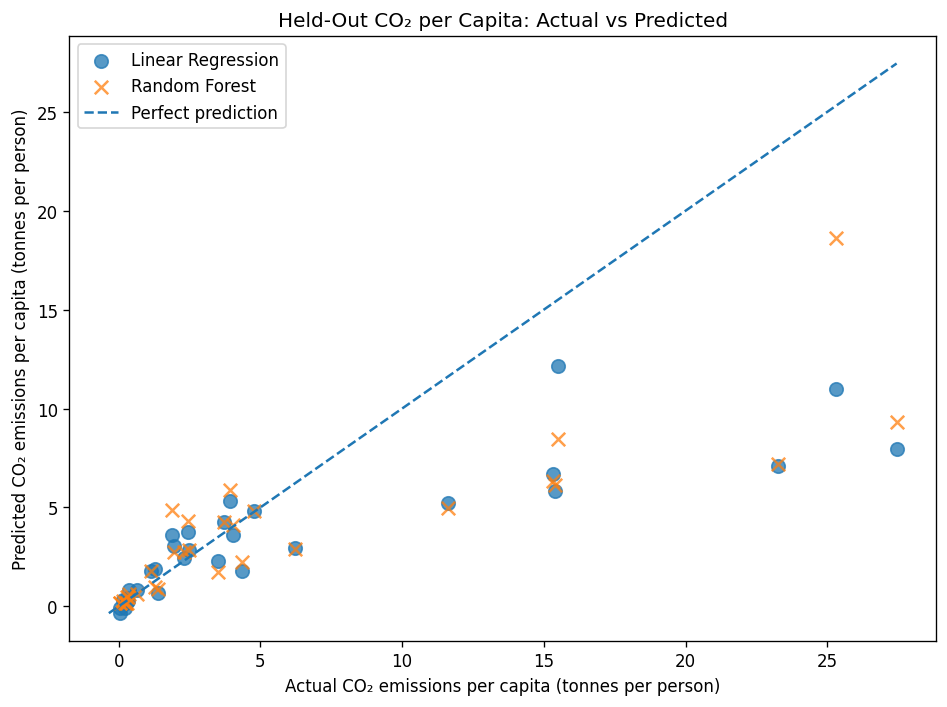


PHILIPPINES MODEL CHECK
Actual CO₂ per capita:            1.287
Linear-model fitted estimate:     2.479
Random-forest fitted estimate:    1.645

These fitted values are diagnostic only. They are not causal estimates or forecasts.


In [8]:
# ============================================================
# EXPLORATORY PREDICTIVE MODELING
# ============================================================

# ------------------------------------------------------------
# 1. BUILD MODELING DATASET
# ------------------------------------------------------------

model_raw_features = [
    "renewable_share_pct",
    "coal_share_pct",
    "gas_share_pct",
    "oil_share_pct",
    "gdp_per_capita_current_usd",
]

model_target = "co2_per_capita"

model_data = (
    country_level[
        [
            "country_code",
            "country_name",
        ]
        + model_raw_features
        + [model_target]
    ]
    .dropna()
    .copy()
    .reset_index(drop=True)
)

# Transform the highly skewed GDP predictor.
model_data["log_gdp_per_capita"] = np.log1p(
    model_data["gdp_per_capita_current_usd"]
)

# Log-transform the target during fitting.
model_data["log_co2_per_capita"] = np.log1p(
    model_data["co2_per_capita"]
)

model_features = [
    "renewable_share_pct",
    "coal_share_pct",
    "gas_share_pct",
    "oil_share_pct",
    "log_gdp_per_capita",
]

print("=" * 80)
print("PREDICTIVE MODELING SAMPLE")
print("=" * 80)
print(
    f"Countries available:             "
    f"{len(country_level)}"
)
print(
    f"Countries retained for modeling: "
    f"{len(model_data)}"
)
print(
    f"Countries excluded:              "
    f"{len(country_level) - len(model_data)}"
)
print(
    "Philippines retained:            "
    f"{model_data['country_code'].eq('PHL').any()}"
)


# ------------------------------------------------------------
# 2. MULTICOLLINEARITY CHECK
# ------------------------------------------------------------

predictor_corr = (
    model_data[model_features]
    .corr()
)

print("\nPREDICTOR CORRELATION MATRIX")
display(
    predictor_corr.round(3)
)

# Calculate VIF without requiring an additional package.
vif_rows = []

for feature in model_features:

    other_features = [
        col for col in model_features
        if col != feature
    ]

    vif_regression = LinearRegression()

    vif_regression.fit(
        model_data[other_features],
        model_data[feature],
    )

    r2_feature = vif_regression.score(
        model_data[other_features],
        model_data[feature],
    )

    vif_value = (
        1 / (1 - r2_feature)
        if r2_feature < 1
        else np.inf
    )

    vif_rows.append({
        "feature": feature,
        "vif": vif_value,
    })

vif_table = pd.DataFrame(vif_rows)

print("\nVARIANCE INFLATION FACTORS")
display(
    vif_table.round(3)
)


# ------------------------------------------------------------
# 3. TRAIN / TEST SPLIT
# ------------------------------------------------------------

X_model = model_data[
    model_features
].copy()

y_original = model_data[
    "co2_per_capita"
].copy()

y_log = model_data[
    "log_co2_per_capita"
].copy()

(
    X_train,
    X_test,
    y_train_log,
    y_test_log,
    y_train_original,
    y_test_original,
) = train_test_split(
    X_model,
    y_log,
    y_original,
    test_size=0.20,
    random_state=RANDOM_STATE,
)


# ------------------------------------------------------------
# 4. DEFINE MODELS
# ------------------------------------------------------------

def make_linear_model():
    return Pipeline([
        (
            "scaler",
            StandardScaler(),
        ),
        (
            "regressor",
            LinearRegression(),
        ),
    ])


def make_rf_model():
    return RandomForestRegressor(
        n_estimators=500,
        min_samples_leaf=3,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )


linear_model = make_linear_model()
rf_model = make_rf_model()


# ------------------------------------------------------------
# 5. FIT MODELS ON LOG-TRANSFORMED CO2 PER CAPITA
# ------------------------------------------------------------

linear_model.fit(
    X_train,
    y_train_log,
)

rf_model.fit(
    X_train,
    y_train_log,
)


# Convert log-scale predictions back to tonnes/person.
linear_train_pred = np.expm1(
    linear_model.predict(X_train)
)

linear_test_pred = np.expm1(
    linear_model.predict(X_test)
)

rf_train_pred = np.expm1(
    rf_model.predict(X_train)
)

rf_test_pred = np.expm1(
    rf_model.predict(X_test)
)


# ------------------------------------------------------------
# 6. METRIC FUNCTION
# ------------------------------------------------------------

def regression_metrics(
    y_train,
    train_pred,
    y_test,
    test_pred,
):
    return {
        "train_r2": r2_score(
            y_train,
            train_pred,
        ),
        "test_r2": r2_score(
            y_test,
            test_pred,
        ),
        "test_mae": mean_absolute_error(
            y_test,
            test_pred,
        ),
        "test_rmse": np.sqrt(
            mean_squared_error(
                y_test,
                test_pred,
            )
        ),
    }


linear_metrics = regression_metrics(
    y_train_original,
    linear_train_pred,
    y_test_original,
    linear_test_pred,
)

rf_metrics = regression_metrics(
    y_train_original,
    rf_train_pred,
    y_test_original,
    rf_test_pred,
)


# ------------------------------------------------------------
# 7. FIVE-FOLD OUT-OF-SAMPLE VALIDATION
# ------------------------------------------------------------

def five_fold_validation(
    X,
    y_log_values,
    y_original_values,
    model_factory,
    n_splits=5,
):

    rng = np.random.RandomState(
        RANDOM_STATE
    )

    shuffled_indices = rng.permutation(
        len(X)
    )

    folds = np.array_split(
        shuffled_indices,
        n_splits,
    )

    oof_predictions = np.full(
        len(X),
        np.nan,
    )

    fold_r2_scores = []

    for fold_indices in folds:

        train_indices = np.setdiff1d(
            np.arange(len(X)),
            fold_indices,
        )

        fold_model = model_factory()

        fold_model.fit(
            X.iloc[train_indices],
            y_log_values.iloc[train_indices],
        )

        fold_pred = np.expm1(
            fold_model.predict(
                X.iloc[fold_indices]
            )
        )

        oof_predictions[
            fold_indices
        ] = fold_pred

        fold_r2_scores.append(
            r2_score(
                y_original_values.iloc[
                    fold_indices
                ],
                fold_pred,
            )
        )

    return {
        "oof_predictions":
            oof_predictions,

        "cv_r2":
            r2_score(
                y_original_values,
                oof_predictions,
            ),

        "cv_mae":
            mean_absolute_error(
                y_original_values,
                oof_predictions,
            ),

        "cv_rmse":
            np.sqrt(
                mean_squared_error(
                    y_original_values,
                    oof_predictions,
                )
            ),

        "fold_r2_mean":
            np.mean(fold_r2_scores),

        "fold_r2_std":
            np.std(fold_r2_scores),
    }


linear_cv = five_fold_validation(
    X_model,
    y_log,
    y_original,
    make_linear_model,
)

rf_cv = five_fold_validation(
    X_model,
    y_log,
    y_original,
    make_rf_model,
)


# ------------------------------------------------------------
# 8. MODEL COMPARISON TABLE
# ------------------------------------------------------------

model_metrics = pd.DataFrame([
    {
        "model": "Linear Regression",
        "n_countries": len(model_data),
        **linear_metrics,
        "cv_r2": linear_cv["cv_r2"],
        "cv_mae": linear_cv["cv_mae"],
        "cv_rmse": linear_cv["cv_rmse"],
        "fold_r2_mean":
            linear_cv["fold_r2_mean"],
        "fold_r2_std":
            linear_cv["fold_r2_std"],
    },
    {
        "model": "Random Forest",
        "n_countries": len(model_data),
        **rf_metrics,
        "cv_r2": rf_cv["cv_r2"],
        "cv_mae": rf_cv["cv_mae"],
        "cv_rmse": rf_cv["cv_rmse"],
        "fold_r2_mean":
            rf_cv["fold_r2_mean"],
        "fold_r2_std":
            rf_cv["fold_r2_std"],
    },
])

model_metrics["train_test_r2_gap"] = (
    model_metrics["train_r2"]
    - model_metrics["test_r2"]
)

print("\n" + "=" * 80)
print("MODEL PERFORMANCE")
print("=" * 80)

display(
    model_metrics.style.format({
        "train_r2": "{:.3f}",
        "test_r2": "{:.3f}",
        "test_mae": "{:.3f}",
        "test_rmse": "{:.3f}",
        "cv_r2": "{:.3f}",
        "cv_mae": "{:.3f}",
        "cv_rmse": "{:.3f}",
        "fold_r2_mean": "{:.3f}",
        "fold_r2_std": "{:.3f}",
        "train_test_r2_gap": "{:.3f}",
    })
)


# ------------------------------------------------------------
# 9. LINEAR MODEL COEFFICIENTS
# ------------------------------------------------------------
# Because the predictors were standardized and the target was
# modeled as log(CO2 per capita + 1), coefficients are best
# interpreted by direction and relative magnitude rather than
# as direct tonnes/person changes.

linear_coefficients = pd.DataFrame({
    "feature": model_features,
    "standardized_coefficient":
        linear_model
        .named_steps["regressor"]
        .coef_,
})

linear_coefficients[
    "absolute_coefficient"
] = (
    linear_coefficients[
        "standardized_coefficient"
    ].abs()
)

linear_coefficients = (
    linear_coefficients
    .sort_values(
        "absolute_coefficient",
        ascending=False,
    )
    .reset_index(drop=True)
)

print("\nLINEAR REGRESSION COEFFICIENTS")
display(
    linear_coefficients[
        [
            "feature",
            "standardized_coefficient",
        ]
    ].round(3)
)


# ------------------------------------------------------------
# 10. HELD-OUT ACTUAL VS PREDICTED FIGURE
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(8, 6)
)

ax.scatter(
    y_test_original,
    linear_test_pred,
    alpha=0.75,
    s=65,
    label="Linear Regression",
)

ax.scatter(
    y_test_original,
    rf_test_pred,
    alpha=0.75,
    s=65,
    marker="x",
    label="Random Forest",
)

plot_min = min(
    y_test_original.min(),
    linear_test_pred.min(),
    rf_test_pred.min(),
)

plot_max = max(
    y_test_original.max(),
    linear_test_pred.max(),
    rf_test_pred.max(),
)

ax.plot(
    [plot_min, plot_max],
    [plot_min, plot_max],
    linestyle="--",
    linewidth=1.5,
    label="Perfect prediction",
)

ax.set_title(
    "Held-Out CO₂ per Capita: Actual vs Predicted"
)

ax.set_xlabel(
    "Actual CO₂ emissions per capita "
    "(tonnes per person)"
)

ax.set_ylabel(
    "Predicted CO₂ emissions per capita "
    "(tonnes per person)"
)

ax.legend()

fig.tight_layout()

fig.savefig(
    OUTPUT_DIR
    / "09_model_actual_vs_predicted_diagnostic.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()


# ------------------------------------------------------------
# 11. PHILIPPINES MODEL DIAGNOSTIC
# ------------------------------------------------------------

phl_model_row = model_data.loc[
    model_data["country_code"].eq("PHL")
].copy()

phl_X = phl_model_row[
    model_features
]

phl_linear_prediction = float(
    np.expm1(
        linear_model.predict(phl_X)[0]
    )
)

phl_rf_prediction = float(
    np.expm1(
        rf_model.predict(phl_X)[0]
    )
)

phl_actual_co2_pc = float(
    phl_model_row[
        "co2_per_capita"
    ].iloc[0]
)

print("\nPHILIPPINES MODEL CHECK")
print(
    f"Actual CO₂ per capita:            "
    f"{phl_actual_co2_pc:.3f}"
)
print(
    f"Linear-model fitted estimate:     "
    f"{phl_linear_prediction:.3f}"
)
print(
    f"Random-forest fitted estimate:    "
    f"{phl_rf_prediction:.3f}"
)

print(
    "\nThese fitted values are diagnostic only. "
    "They are not causal estimates or forecasts."
)

## Philippine Installed-Capacity Shift Scenarios

The final analysis examines three hypothetical changes to the Philippine installed-capacity mix.

Starting from the observed 2019 Philippine profile, the scenarios shift:

- **Scenario A:** 5 percentage points of installed capacity from coal to renewable sources;
- **Scenario B:** 10 percentage points from coal to renewable sources; and
- **Scenario C:** 20 percentage points from coal to renewable sources.

Total installed capacity is held constant. Gas, oil, other fossil sources, and other or unclassified capacity are also held constant. Only the allocation between coal and renewable installed capacity changes.

These scenarios represent hypothetical **installed-capacity reallocations**, not forecasts of actual electricity generation, construction requirements, retirement schedules, or future national emissions.

The exploratory predictive models developed in the previous section are not used to estimate scenario emissions. Although the models showed moderate predictive performance, the installed-capacity variables exhibited substantial multicollinearity and the Philippine fitted values did not reproduce the observed Philippine CO₂-per-capita value closely enough to support country-specific emissions projections.

The scenarios therefore answer a narrower and more defensible question:

**How would the Philippine installed-capacity profile change if 5, 10, or 20 percentage points of coal capacity were hypothetically reallocated to renewable capacity while total installed capacity remained constant?**

PHILIPPINE INSTALLED-CAPACITY SHIFT SCENARIOS


,scenario,coal_to_renewable_shift_pp,shifted_capacity_mw,coal_share_pct,renewable_share_pct,fossil_share_pct,other_fossil_share_pct,total_installed_capacity_mw
0,Current,0,0.0,42.1,31.5,68.5,26.4,"20,719.3"
1,Scenario A: 5 pp shift,5,"1,036.0",37.1,36.5,63.5,26.4,"20,719.3"
2,Scenario B: 10 pp shift,10,"2,071.9",32.1,41.5,58.5,26.4,"20,719.3"
3,Scenario C: 20 pp shift,20,"4,143.9",22.1,51.5,48.5,26.4,"20,719.3"


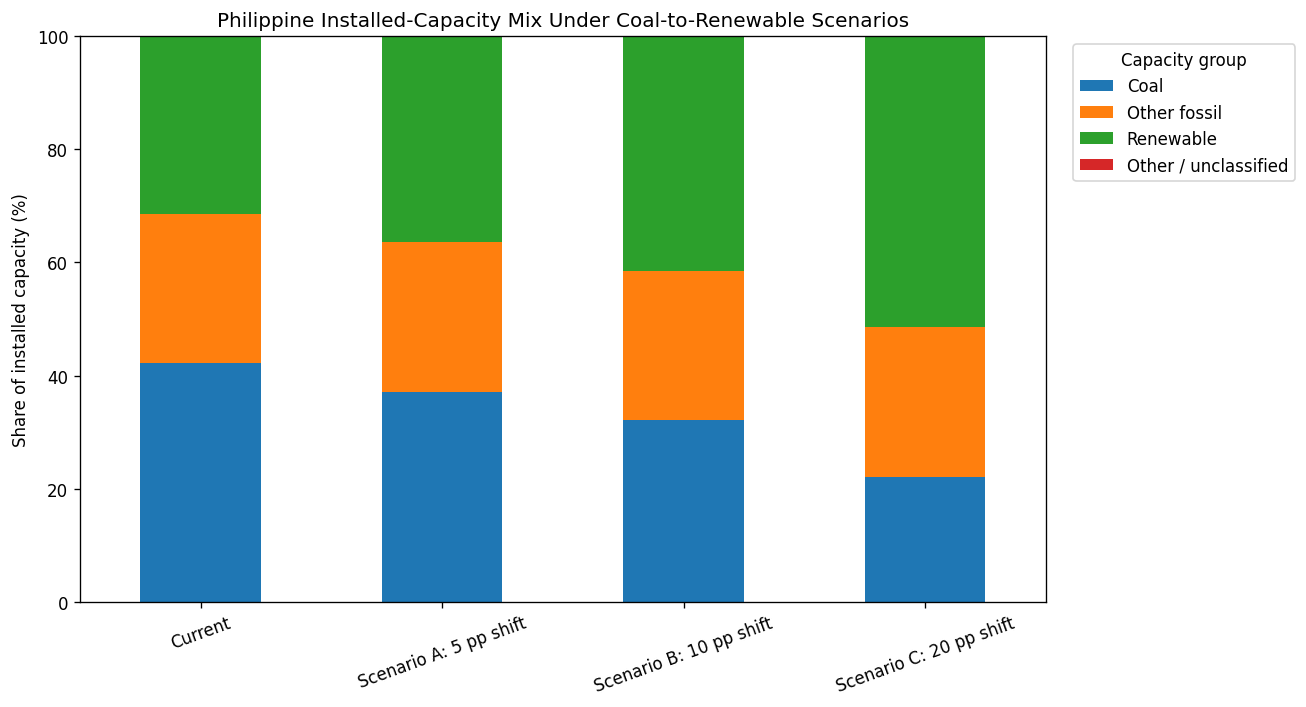

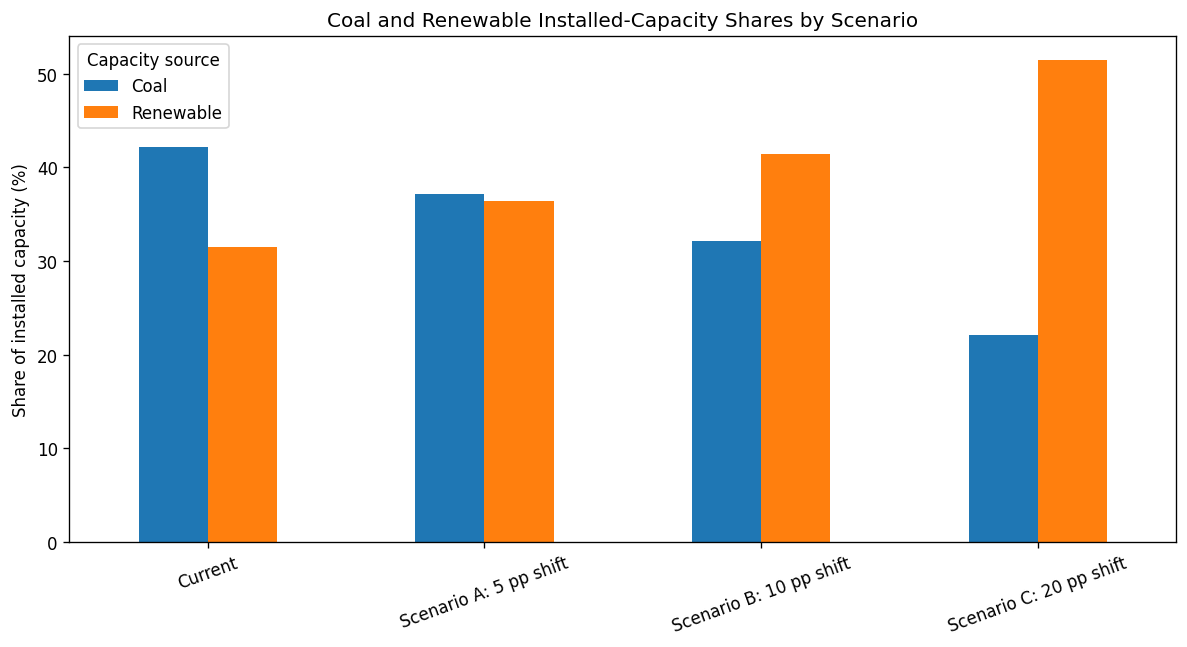


FILES SAVED
/content/outputs/analysis/philippines_scenarios.csv
/content/outputs/analysis/model_metrics.csv
/content/outputs/analysis/10_philippines_capacity_shift_scenarios.png
/content/outputs/analysis/11_philippines_coal_renewable_scenarios.png


In [9]:
# ============================================================
# PHILIPPINE INSTALLED-CAPACITY SHIFT SCENARIOS
# ============================================================

# ------------------------------------------------------------
# 1. CURRENT PHILIPPINE VALUES
# ------------------------------------------------------------

phl = (
    country_level.loc[
        country_level["country_code"].eq("PHL")
    ]
    .iloc[0]
)

total_capacity = float(
    phl["total_installed_capacity_mw"]
)

current_coal = float(
    phl["coal_share_pct"]
)

current_renewable = float(
    phl["renewable_share_pct"]
)

current_fossil = float(
    phl["fossil_share_pct"]
)

current_other = float(
    phl["other_or_unclassified_share_pct"]
)

# Fossil capacity other than coal remains unchanged
# throughout the scenarios.
current_other_fossil = (
    current_fossil - current_coal
)

scenario_shifts = {
    "Current": 0,
    "Scenario A: 5 pp shift": 5,
    "Scenario B: 10 pp shift": 10,
    "Scenario C: 20 pp shift": 20,
}

# Make sure requested scenarios are feasible.
max_shift = max(scenario_shifts.values())

if max_shift > current_coal:
    raise ValueError(
        "Requested coal-capacity shift exceeds "
        "the current Philippine coal share."
    )


# ------------------------------------------------------------
# 2. BUILD SCENARIO TABLE
# ------------------------------------------------------------

scenario_rows = []

for scenario_name, shift_pp in scenario_shifts.items():

    coal_share = (
        current_coal - shift_pp
    )

    renewable_share = (
        current_renewable + shift_pp
    )

    fossil_share = (
        current_fossil - shift_pp
    )

    shifted_capacity_mw = (
        total_capacity
        * shift_pp
        / 100
    )

    scenario_rows.append({
        "scenario": scenario_name,
        "coal_to_renewable_shift_pp":
            shift_pp,

        "total_installed_capacity_mw":
            total_capacity,

        "shifted_capacity_mw":
            shifted_capacity_mw,

        "coal_share_pct":
            coal_share,

        "other_fossil_share_pct":
            current_other_fossil,

        "fossil_share_pct":
            fossil_share,

        "renewable_share_pct":
            renewable_share,

        "other_or_unclassified_share_pct":
            current_other,

        "coal_capacity_mw":
            total_capacity
            * coal_share
            / 100,

        "renewable_capacity_mw":
            total_capacity
            * renewable_share
            / 100,

        "fossil_capacity_mw":
            total_capacity
            * fossil_share
            / 100,
    })

philippines_scenarios = pd.DataFrame(
    scenario_rows
)


# ------------------------------------------------------------
# 3. VALIDATE SCENARIOS
# ------------------------------------------------------------

# Total installed capacity must remain unchanged.
assert np.allclose(
    philippines_scenarios[
        "total_installed_capacity_mw"
    ],
    total_capacity,
)

# Coal cannot become negative.
assert (
    philippines_scenarios[
        "coal_share_pct"
    ] >= 0
).all()

# Shares must remain within valid limits.
for col in [
    "coal_share_pct",
    "other_fossil_share_pct",
    "fossil_share_pct",
    "renewable_share_pct",
    "other_or_unclassified_share_pct",
]:
    assert philippines_scenarios[
        col
    ].between(
        0,
        100.01,
        inclusive="both",
    ).all()

# Renewable + fossil + other must still total ~100%.
share_total = (
    philippines_scenarios[
        "renewable_share_pct"
    ]
    + philippines_scenarios[
        "fossil_share_pct"
    ]
    + philippines_scenarios[
        "other_or_unclassified_share_pct"
    ]
)

assert np.allclose(
    share_total,
    100,
    atol=0.01,
)

# The MW shifted away from coal must equal
# the MW added to renewables.
coal_capacity_change = (
    philippines_scenarios.loc[
        0,
        "coal_capacity_mw"
    ]
    - philippines_scenarios[
        "coal_capacity_mw"
    ]
)

renewable_capacity_change = (
    philippines_scenarios[
        "renewable_capacity_mw"
    ]
    - philippines_scenarios.loc[
        0,
        "renewable_capacity_mw"
    ]
)

assert np.allclose(
    coal_capacity_change,
    renewable_capacity_change,
)


# ------------------------------------------------------------
# 4. DISPLAY SCENARIO RESULTS
# ------------------------------------------------------------

print("=" * 80)
print("PHILIPPINE INSTALLED-CAPACITY SHIFT SCENARIOS")
print("=" * 80)

scenario_display = philippines_scenarios[
    [
        "scenario",
        "coal_to_renewable_shift_pp",
        "shifted_capacity_mw",
        "coal_share_pct",
        "renewable_share_pct",
        "fossil_share_pct",
        "other_fossil_share_pct",
        "total_installed_capacity_mw",
    ]
].copy()

display(
    scenario_display.style.format({
        "coal_to_renewable_shift_pp":
            "{:.0f}",
        "shifted_capacity_mw":
            "{:,.1f}",
        "coal_share_pct":
            "{:.1f}",
        "renewable_share_pct":
            "{:.1f}",
        "fossil_share_pct":
            "{:.1f}",
        "other_fossil_share_pct":
            "{:.1f}",
        "total_installed_capacity_mw":
            "{:,.1f}",
    })
)


# ------------------------------------------------------------
# 5. PRESENTATION-READY STACKED CAPACITY-MIX FIGURE
# ------------------------------------------------------------

scenario_plot = (
    philippines_scenarios[
        [
            "scenario",
            "coal_share_pct",
            "other_fossil_share_pct",
            "renewable_share_pct",
            "other_or_unclassified_share_pct",
        ]
    ]
    .set_index("scenario")
    .rename(
        columns={
            "coal_share_pct":
                "Coal",
            "other_fossil_share_pct":
                "Other fossil",
            "renewable_share_pct":
                "Renewable",
            "other_or_unclassified_share_pct":
                "Other / unclassified",
        }
    )
)

ax = scenario_plot.plot(
    kind="bar",
    stacked=True,
    figsize=(11, 6),
)

ax.set_title(
    "Philippine Installed-Capacity Mix Under Coal-to-Renewable Scenarios"
)

ax.set_xlabel("")
ax.set_ylabel(
    "Share of installed capacity (%)"
)

ax.set_ylim(0, 100)

ax.legend(
    title="Capacity group",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

ax.tick_params(
    axis="x",
    rotation=20,
)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR
    / "10_philippines_capacity_shift_scenarios.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()


# ------------------------------------------------------------
# 6. SECOND FIGURE — COAL VS RENEWABLE SHARE
# ------------------------------------------------------------

comparison_plot = (
    philippines_scenarios[
        [
            "scenario",
            "coal_share_pct",
            "renewable_share_pct",
        ]
    ]
    .set_index("scenario")
    .rename(
        columns={
            "coal_share_pct":
                "Coal",
            "renewable_share_pct":
                "Renewable",
        }
    )
)

ax = comparison_plot.plot(
    kind="bar",
    figsize=(10, 5.5),
)

ax.set_title(
    "Coal and Renewable Installed-Capacity Shares by Scenario"
)

ax.set_xlabel("")
ax.set_ylabel(
    "Share of installed capacity (%)"
)

ax.tick_params(
    axis="x",
    rotation=20,
)

ax.legend(
    title="Capacity source"
)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR
    / "11_philippines_coal_renewable_scenarios.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()


# ------------------------------------------------------------
# 7. SAVE SCENARIO OUTPUT
# ------------------------------------------------------------

philippines_scenarios.to_csv(
    OUTPUT_DIR
    / "philippines_scenarios.csv",
    index=False,
)

# The predictive component was retained, so save its metrics.
model_metrics.to_csv(
    OUTPUT_DIR
    / "model_metrics.csv",
    index=False,
)

print("\nFILES SAVED")
print(
    OUTPUT_DIR
    / "philippines_scenarios.csv"
)
print(
    OUTPUT_DIR
    / "model_metrics.csv"
)
print(
    OUTPUT_DIR
    / "10_philippines_capacity_shift_scenarios.png"
)
print(
    OUTPUT_DIR
    / "11_philippines_coal_renewable_scenarios.png"
)

## Key Findings and Limitations

The analysis demonstrates how the project's plant-level data-engineering pipeline can support a country-level exploratory comparison of energy structure, emissions, and economic conditions.

The final clustering analysis uses countries with complete information for the selected installed-capacity, carbon-intensity, and economic variables. Four country clusters were selected based on the combined evidence from the elbow method and silhouette analysis.

The Philippines belongs to a cluster characterized by relatively high coal installed-capacity shares and higher average carbon intensity. However, the Philippine profile should not be interpreted as identical to the cluster average. Its renewable capacity share is higher, its coal share is lower, and its observed carbon indicators are substantially lower than the average values of its cluster.

Within the Philippine cluster, peer countries were evaluated using both standardized similarity and transparent capacity-mix comparisons. Morocco, Laos, and Vietnam emerged as potential **cleaner installed-capacity benchmarks** because they combine broadly comparable economic conditions with higher renewable capacity shares and lower fossil and coal shares than the Philippines.

These countries do not, however, have lower CO₂ per capita or lower CO₂ per GDP than the Philippines. The benchmark therefore concerns the structure of installed electricity capacity rather than overall national carbon performance.

The optional predictive analysis found moderate associations between installed-capacity structure, GDP per capita, and CO₂ emissions per capita. However, substantial multicollinearity among the capacity-share variables and imperfect Philippine-specific prediction make the models unsuitable for estimating emissions reductions from the hypothetical Philippine scenarios.

The scenario analysis is therefore limited to changes in installed-capacity composition. It shows the mathematical implications of reallocating 5, 10, or 20 percentage points of coal capacity toward renewable capacity while keeping total installed capacity constant.

### Limitations

This analysis has several important limitations:

- The study uses a cross-sectional 2019 snapshot and therefore cannot establish temporal or causal relationships.
- Installed generation capacity is not equivalent to actual electricity generation. A country's capacity mix does not show how frequently individual plants operate or how much electricity each fuel source actually produces.
- National CO₂ and greenhouse-gas indicators cover broader economic activity than electricity generation alone.
- Country comparisons do not control for differences in geography, resource availability, electricity demand, grid structure, trade, industrial composition, or energy policy.
- Fifteen countries were excluded from clustering because one or more selected clustering variables were unavailable.
- K-Means requires numerical scaling and assumes distance-based grouping. The resulting clusters are exploratory analytical groupings rather than natural or definitive classifications of countries.
- The cluster labels are interpretive summaries assigned after examining the cluster profiles.
- Capacity-share variables are compositional and therefore mathematically interdependent. This contributed to multicollinearity in the predictive model.
- The predictive models describe associations rather than causal effects and are not used to forecast emissions under the Philippine capacity-shift scenarios.
- The hypothetical scenarios do not account for construction feasibility, plant retirement schedules, intermittency, grid requirements, costs, capacity factors, electricity demand, or implementation timelines.

The results should therefore be interpreted as **exploratory benchmarking and decision support**, not as causal evidence or a prescriptive energy-transition plan.

In [10]:
# ============================================================
# FINAL OUTPUTS, DATA-DRIVEN FINDINGS, AND NOTEBOOK QA
# ============================================================

# ------------------------------------------------------------
# 1. FINALIZE REQUIRED EXPORT TABLES
# ------------------------------------------------------------

# Final country-level analysis file
country_level.to_csv(
    OUTPUT_DIR / "country_level_analysis.csv",
    index=False,
)

# Final cluster file with interpretive labels
country_clusters.to_csv(
    OUTPUT_DIR / "country_clusters.csv",
    index=False,
)

# Philippine peer comparison
philippines_peer_comparison.to_csv(
    OUTPUT_DIR / "philippines_peer_comparison.csv",
    index=False,
)

# Philippine scenarios
philippines_scenarios.to_csv(
    OUTPUT_DIR / "philippines_scenarios.csv",
    index=False,
)

# Predictive model metrics retained as an exploratory output
model_metrics.to_csv(
    OUTPUT_DIR / "model_metrics.csv",
    index=False,
)


# ------------------------------------------------------------
# 2. FINAL VALUES FOR AUTOMATIC SUMMARY
# ------------------------------------------------------------

n_total_countries = len(country_level)

n_clustered = int(
    country_clusters[
        "included_in_clustering"
    ].sum()
)

n_excluded_cluster = (
    n_total_countries - n_clustered
)

final_k = FINAL_K

phl_final = (
    country_clusters.loc[
        country_clusters[
            "country_code"
        ].eq("PHL")
    ]
    .iloc[0]
)

phl_cluster_final = int(
    phl_final["cluster"]
)

phl_cluster_label = (
    cluster_label_map[
        phl_cluster_final
    ]
)

phl_cluster_profile = (
    cluster_profiles.loc[
        cluster_profiles[
            "cluster"
        ].eq(phl_cluster_final)
    ]
    .iloc[0]
)

# Benchmark names selected by transparent criteria
benchmark_names = (
    benchmark_candidates[
        "country_name"
    ]
    .tolist()
)

if benchmark_names:
    benchmark_text = ", ".join(
        benchmark_names
    )
else:
    benchmark_text = (
        "No countries met all predefined "
        "benchmark criteria"
    )


# ------------------------------------------------------------
# 3. BUILD PEER DIFFERENCE TABLE
# ------------------------------------------------------------

peer_differences = (
    philippines_peer_comparison.loc[
        ~philippines_peer_comparison[
            "country_code"
        ].eq("PHL")
    ]
    .copy()
)

peer_differences[
    "renewable_difference_vs_phl_pp"
] = (
    peer_differences[
        "renewable_share_pct"
    ]
    - phl_final[
        "renewable_share_pct"
    ]
)

peer_differences[
    "fossil_difference_vs_phl_pp"
] = (
    peer_differences[
        "fossil_share_pct"
    ]
    - phl_final[
        "fossil_share_pct"
    ]
)

peer_differences[
    "coal_difference_vs_phl_pp"
] = (
    peer_differences[
        "coal_share_pct"
    ]
    - phl_final[
        "coal_share_pct"
    ]
)

peer_differences[
    "co2_per_capita_difference_vs_phl"
] = (
    peer_differences[
        "co2_per_capita"
    ]
    - phl_final[
        "co2_per_capita"
    ]
)

peer_differences[
    "co2_per_gdp_difference_vs_phl"
] = (
    peer_differences[
        "co2_per_gdp"
    ]
    - phl_final[
        "co2_per_gdp"
    ]
)


# ------------------------------------------------------------
# 4. SCENARIO VALUES
# ------------------------------------------------------------

scenario_a = philippines_scenarios.loc[
    philippines_scenarios[
        "coal_to_renewable_shift_pp"
    ].eq(5)
].iloc[0]

scenario_b = philippines_scenarios.loc[
    philippines_scenarios[
        "coal_to_renewable_shift_pp"
    ].eq(10)
].iloc[0]

scenario_c = philippines_scenarios.loc[
    philippines_scenarios[
        "coal_to_renewable_shift_pp"
    ].eq(20)
].iloc[0]


# ------------------------------------------------------------
# 5. PREDICTIVE MODEL SUMMARY
# ------------------------------------------------------------

linear_result = (
    model_metrics.loc[
        model_metrics[
            "model"
        ].eq("Linear Regression")
    ]
    .iloc[0]
)

rf_result = (
    model_metrics.loc[
        model_metrics[
            "model"
        ].eq("Random Forest")
    ]
    .iloc[0]
)


# ------------------------------------------------------------
# 6. AUTOMATICALLY GENERATED FINAL FINDINGS
# ------------------------------------------------------------

print("=" * 88)
print("FINAL DATA-DRIVEN FINDINGS")
print("=" * 88)

print(
    f"\n1. CLUSTERING SAMPLE\n"
    f"The country-level dataset contains "
    f"{n_total_countries} countries. "
    f"{n_clustered} countries had complete values for "
    f"the selected clustering variables and were included "
    f"in K-Means; {n_excluded_cluster} were excluded because "
    f"of missing clustering inputs."
)

print(
    f"\n2. NUMBER OF CLUSTERS\n"
    f"K = {final_k} was selected. It produced the highest "
    f"silhouette score among the tested solutions "
    f"(0.323) and was also supported by the elbow pattern."
)

print(
    f"\n3. PHILIPPINES CLUSTER\n"
    f"The Philippines belongs to Cluster "
    f"{phl_cluster_final}: "
    f"'{phl_cluster_label}'."
)

print(
    f"\n4. CLUSTER CHARACTERISTICS\n"
    f"Cluster {phl_cluster_final} contains "
    f"{int(phl_cluster_profile['country_count'])} countries "
    f"and has mean installed-capacity shares of "
    f"{phl_cluster_profile['renewable_share_pct']:.1f}% "
    f"renewable, "
    f"{phl_cluster_profile['fossil_share_pct']:.1f}% fossil, "
    f"and {phl_cluster_profile['coal_share_pct']:.1f}% coal. "
    f"Its mean CO₂-per-GDP indicator is "
    f"{phl_cluster_profile['co2_per_gdp']:.3f}."
)

print(
    f"\n5. PHILIPPINE PROFILE\n"
    f"The Philippines has "
    f"{phl_final['renewable_share_pct']:.1f}% renewable, "
    f"{phl_final['fossil_share_pct']:.1f}% fossil, and "
    f"{phl_final['coal_share_pct']:.1f}% coal installed "
    f"capacity. Its observed CO₂ per capita is "
    f"{phl_final['co2_per_capita']:.2f} tonnes/person and "
    f"its CO₂-per-GDP indicator is "
    f"{phl_final['co2_per_gdp']:.3f}."
)

print(
    f"\n6. CLEANER INSTALLED-CAPACITY BENCHMARKS\n"
    f"Using the predefined same-cluster, economic-comparability, "
    f"higher-renewable, lower-fossil, and lower-coal criteria, "
    f"the potential benchmarks are: {benchmark_text}."
)

if not peer_differences.empty:

    print(
        "\n7. PEER CAPACITY COMPARISON"
    )

    for _, row in (
        peer_differences
        .sort_values(
            "renewable_share_pct",
            ascending=False
        )
        .iterrows()
    ):

        print(
            f"- {row['country_name']}: "
            f"renewable share "
            f"{row['renewable_share_pct']:.1f}% "
            f"({row['renewable_difference_vs_phl_pp']:+.1f} pp "
            f"vs Philippines), "
            f"coal share "
            f"{row['coal_share_pct']:.1f}% "
            f"({row['coal_difference_vs_phl_pp']:+.1f} pp), "
            f"and fossil share "
            f"{row['fossil_share_pct']:.1f}% "
            f"({row['fossil_difference_vs_phl_pp']:+.1f} pp)."
        )

print(
    f"\n8. CARBON-INDICATOR COMPARISON\n"
    f"None of the selected cleaner installed-capacity benchmarks "
    f"has a lower CO₂-per-capita or CO₂-per-GDP value than "
    f"the Philippines. This means that a cleaner installed-"
    f"capacity structure does not automatically correspond to "
    f"lower overall national carbon indicators in this "
    f"cross-sectional dataset."
)

print(
    f"\n9. PREDICTIVE MODEL\n"
    f"The exploratory Linear Regression achieved "
    f"test R² = {linear_result['test_r2']:.3f} and "
    f"five-fold out-of-sample R² = "
    f"{linear_result['cv_r2']:.3f}. "
    f"The Random Forest achieved "
    f"test R² = {rf_result['test_r2']:.3f} and "
    f"five-fold out-of-sample R² = "
    f"{rf_result['cv_r2']:.3f}. "
    f"The models were retained as exploratory evidence of "
    f"association but were not used to predict scenario "
    f"emissions because of multicollinearity and limited "
    f"Philippine-specific calibration."
)

print(
    f"\n10. CAPACITY-SHIFT SCENARIOS\n"
    f"Current Philippine installed capacity is "
    f"{phl_final['total_installed_capacity_mw']:,.1f} MW, "
    f"with coal at "
    f"{phl_final['coal_share_pct']:.1f}% and renewables at "
    f"{phl_final['renewable_share_pct']:.1f}%."
)

print(
    f"- A 5-percentage-point shift represents approximately "
    f"{scenario_a['shifted_capacity_mw']:,.1f} MW and changes "
    f"coal to {scenario_a['coal_share_pct']:.1f}% and "
    f"renewables to "
    f"{scenario_a['renewable_share_pct']:.1f}%."
)

print(
    f"- A 10-percentage-point shift represents approximately "
    f"{scenario_b['shifted_capacity_mw']:,.1f} MW and changes "
    f"coal to {scenario_b['coal_share_pct']:.1f}% and "
    f"renewables to "
    f"{scenario_b['renewable_share_pct']:.1f}%."
)

print(
    f"- A 20-percentage-point shift represents approximately "
    f"{scenario_c['shifted_capacity_mw']:,.1f} MW and changes "
    f"coal to {scenario_c['coal_share_pct']:.1f}% and "
    f"renewables to "
    f"{scenario_c['renewable_share_pct']:.1f}%. "
    f"Under this hypothetical mix, renewables exceed half of "
    f"installed capacity and total fossil capacity falls to "
    f"{scenario_c['fossil_share_pct']:.1f}%."
)

print(
    "\n11. INTERPRETATION\n"
    "The analysis supports the use of country clustering and "
    "transparent peer benchmarking to identify alternative "
    "installed-capacity profiles. It does not establish that "
    "adopting another country's capacity mix would cause the "
    "Philippines to achieve the same emissions outcome."
)


# ------------------------------------------------------------
# 7. FINAL REQUIRED OUTPUT QA
# ------------------------------------------------------------

required_csv_files = [
    "country_level_analysis.csv",
    "country_clusters.csv",
    "philippines_peer_comparison.csv",
    "philippines_scenarios.csv",
    "model_metrics.csv",
]

required_figure_files = [
    "01_renewable_share_distribution.png",
    "02_renewable_vs_co2_per_capita.png",
    "03_kmeans_elbow_curve.png",
    "04_kmeans_silhouette_scores.png",
    "05_cluster_profile_heatmap.png",
    "06_country_clusters_pca.png",
    "07_philippines_peer_capacity_comparison.png",
    "08_philippines_peer_co2_per_capita.png",
    "09_model_actual_vs_predicted_diagnostic.png",
    "10_philippines_capacity_shift_scenarios.png",
    "11_philippines_coal_renewable_scenarios.png",
]

all_required_files = (
    required_csv_files
    + required_figure_files
)

output_check = pd.DataFrame({
    "file": all_required_files,
    "exists": [
        (
            OUTPUT_DIR / filename
        ).exists()
        for filename in all_required_files
    ],
})

print("\n" + "=" * 88)
print("FINAL OUTPUT CHECK")
print("=" * 88)

display(output_check)

if output_check["exists"].all():
    print(
        "\nSUCCESS: All required analytical outputs "
        "were generated."
    )
else:
    missing_outputs = output_check.loc[
        ~output_check["exists"],
        "file",
    ].tolist()

    print(
        "\nWARNING: Missing output files:",
        missing_outputs,
    )


# ------------------------------------------------------------
# 8. FINAL DATASET INTEGRITY CHECK
# ------------------------------------------------------------

print("\n" + "=" * 88)
print("FINAL DATASET QA")
print("=" * 88)

print(
    f"Country-level rows: "
    f"{len(country_level)}"
)

print(
    f"Unique country codes: "
    f"{country_level['country_code'].nunique()}"
)

print(
    f"Countries with cluster assignments: "
    f"{country_clusters['cluster'].notna().sum()}"
)

print(
    f"Philippines cluster: "
    f"{phl_cluster_final}"
)

print(
    f"Selected peer countries: "
    f"{len(peer_differences)}"
)

print(
    f"Scenario rows: "
    f"{len(philippines_scenarios)}"
)

assert len(country_level) == (
    country_level[
        "country_code"
    ].nunique()
)

assert country_level[
    "country_code"
].eq("PHL").any()

assert (
    country_clusters.loc[
        country_clusters[
            "included_in_clustering"
        ],
        "cluster",
    ]
    .notna()
    .all()
)

assert len(
    philippines_scenarios
) == 4

print(
    "\nFINAL QA PASSED."
)
print(
    f"All outputs are available in: "
    f"{OUTPUT_DIR}"
)

FINAL DATA-DRIVEN FINDINGS

1. CLUSTERING SAMPLE
The country-level dataset contains 167 countries. 152 countries had complete values for the selected clustering variables and were included in K-Means; 15 were excluded because of missing clustering inputs.

2. NUMBER OF CLUSTERS
K = 4 was selected. It produced the highest silhouette score among the tested solutions (0.323) and was also supported by the elbow pattern.

3. PHILIPPINES CLUSTER
The Philippines belongs to Cluster 4: 'Coal-heavy / higher-carbon-intensity'.

4. CLUSTER CHARACTERISTICS
Cluster 4 contains 30 countries and has mean installed-capacity shares of 24.9% renewable, 69.1% fossil, and 54.9% coal. Its mean CO₂-per-GDP indicator is 0.341.

5. PHILIPPINE PROFILE
The Philippines has 31.5% renewable, 68.5% fossil, and 42.1% coal installed capacity. Its observed CO₂ per capita is 1.29 tonnes/person and its CO₂-per-GDP indicator is 0.145.

6. CLEANER INSTALLED-CAPACITY BENCHMARKS
Using the predefined same-cluster, economic-com

,file,exists
0,country_level_analysis.csv,True
1,country_clusters.csv,True
2,philippines_peer_comparison.csv,True
3,philippines_scenarios.csv,True
4,model_metrics.csv,True
5,01_renewable_share_distribution.png,True
6,02_renewable_vs_co2_per_capita.png,True
7,03_kmeans_elbow_curve.png,True
8,04_kmeans_silhouette_scores.png,True
9,05_cluster_profile_heatmap.png,True



SUCCESS: All required analytical outputs were generated.

FINAL DATASET QA
Country-level rows: 167
Unique country codes: 167
Countries with cluster assignments: 152
Philippines cluster: 4
Selected peer countries: 3
Scenario rows: 4

FINAL QA PASSED.
All outputs are available in: /content/outputs/analysis


In [11]:
# Package all analytical outputs for download
import shutil

shutil.make_archive(
    "/content/group_eta_analysis_outputs",
    "zip",
    OUTPUT_DIR,
)

from google.colab import files
files.download(
    "/content/group_eta_analysis_outputs.zip"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>